In [1]:
print("hi")

hi


## Sarvam ASR Assignment: Diarization Benchmarking & Enhancement
---

**Deadline: Saturday, 22 August 2026, EOD**

You are given a CSV containing 100 YouTube videos with ground-truth diarization labels and reference transcripts. Your task is to parse these labels, benchmark existing diarization and ASR systems on them, and then **improve** the output.

### Input

`youtube_segments.csv` — one row per segment. The csv is present at https://drive.google.com/file/d/1Ijs1IWypIY2GAjpNUKV2XNZY6o7dFvSm/view?usp=sharing

Columns:

- `video_id` — YouTube video id
- `youtube_link` — source URL
- `start_sec`, `end_sec` — the window to extract. Use **only** `[start_sec, end_sec]`.
- `diarization_segments` — **ground-truth diarization**, formatted as `Speaker A [start-end] | Speaker B [start-end] | ...`
- `asr_segments` — **reference transcript** for the same segment, formatted as `[start-end] text | [start-end] text | ...`

`diarization_segments` and `asr_segments` share the **same segment boundaries in the same order** — the *n*-th `asr_segments` entry is the transcript of the *n*-th `diarization_segments` turn — so you can join speaker to text by index or by time. All timestamps are **relative to `start_sec`** (0 = start of the extracted clip).

If for any reason the ground-truth labels look incorrect, hand-label a subset and call out the limitation.

---

### Step 1 - Audio (or Video) Extraction

- Download the **audio** track from each YouTube link (yt-dlp / ffmpeg).
- Trim to `[start_sec, end_sec]`.
- Store as 16 kHz mono WAV.
- Optionally download the **video** track for the same window as well, if you plan to use visual cues in Step 4.

### Step 2 - Baseline Diarization Benchmarking

Run the extracted segments through top open-source diarization models.

Report standard metrics:

- **DER**
- **JER**
- Speaker-count accuracy

**Important:** Do NOT ignore overlapping speech regions when computing metrics. Overlap must be scored.

### Step 3 - ASR on Diarized Segments

Run ASR on the diarized speaker segments to produce speaker-attributed transcripts. Benchmark more than one STT system (e.g. Sarvam Saaras, Whisper, etc.) — the reference transcript in `asr_segments` is what you score against, not a substitute for running ASR yourself. Think about strategies for handling overlapping speech regions during ASR - how do you transcribe segments where multiple speakers are active simultaneously?

Also report:

- **cpWER**
- **WDER**

### Step 4 - Improving the Output

Take the best ASR + diarization combination you found while benchmarking, and build a pipeline on top of it that improves the output. Quantify the improvement over the same metrics as before. It is up to you whether you target diarization, ASR, or both.

**The ground truth is never an input to your pipeline.** `diarization_segments` and `asr_segments` are only for computing the final scores.

You are free to choose the strategy. Some directions:

- **Semantic / LLM-based correction** — feed the speaker-attributed text + timestamps to an LLM to detect and correct boundary errors, speaker confusion, and turn-merging issues. Any LLM is acceptable: paid APIs (GPT, Claude, Gemini, etc.) or open-source models. Prompting strategy, structured-output schema, chain-of-thought, and multi-pass refinement are yours to design.
- **Acoustic and visual cues** — use the video alongside the audio (e.g. active-speaker detection, face tracks, lip motion) to refine speaker boundaries and identities.
- Any combination of the above, or anything else you can justify.

**Hint:** Think about how transcript content can reveal diarization mistakes - e.g. unnaturally short segments, repeated/stuttered text across a speaker boundary suggesting a false split, or incoherent speaker transitions that indicate speaker confusion.

Also include:
- The papers / ideas your design draws from
- Multilingual / Indic-specific observations and failure modes

---

### Deliverables

Mail a Google Drive folder link (with all of the following):

1. A reproducible Colab notebook with the full pipeline end-to-end.
2. A results table: baseline vs. improved DER / JER / cpWER / WDER per model per video.
3. A short writeup (1–2 pages) covering approach, design choices, what worked, what didn't, failure cases, and references.

---

### Evaluation

- Correctness of pipeline and metrics
- Magnitude and consistency of improvement over baseline
- Depth of analysis and engineering judgement
- Clarity of code and writeup
- Breadth of techniques explored (bonus)


    

# Sarvam ASR Assignment — **Kaggle** runner

Identical pipeline to `main.ipynb`; only the platform glue differs. Before you
run anything, in the right-hand panel:

| Setting | Value | Why |
|---|---|---|
| **Internet** | **ON** | `pip install` and the `git clone` both need it. Off by default. |
| **Accelerator** | **GPU T4 x2** (or P100) | Step 2 inference |
| **Input** | your audio dataset | see 1.1 — `audio_16k/` and `meta/` |
| **Add-ons > Secrets** | `HF_TOKEN` | gated pyannote models (optional, see 1.1b) |

Storage differs from Colab: `/kaggle/input` is read-only and `/kaggle/working`
is writable but **wiped between sessions**. Cell 1.1 symlinks the dataset into
the working root so nothing is copied, and `Save Version` persists outputs.

## 1.0 — Setup

Installs `yt-dlp` (keep it current: YouTube extractor breakage is the single
most common cause of failure), mounts Drive, and puts `sarvam_diar/` on the
path. Everything here is cheap and safe to re-run.

In [2]:
# --- dependencies -----------------------------------------------------------
# Kaggle: Settings (right panel) > Internet must be ON, or pip and the git clone
# below both fail. Accelerator > GPU T4 x2 (or P100) for Step 2.
#
# Installed HERE, before any work, because pyannote pulls a newer numpy than the
# image ships. Upgrading numpy under a live kernel leaves the process with
# half-old, half-new modules and the next numpy-touching import dies with
# `cannot import name '_center' from 'numpy._core.umath'`.
%pip install -q --upgrade yt-dlp
%pip install -q gdown "pyannote.audio>=4.0" "pyannote.metrics" itables

# Did an install replace a module this interpreter already imported? A fresh
# subprocess reads what is on disk; the running process reports what it loaded.
import os, shutil, subprocess, sys
from pathlib import Path

_stale = []
for _mod in ("numpy", "scipy"):
    try:
        _loaded = __import__(_mod).__version__
    except Exception:
        continue
    _disk = subprocess.run([sys.executable, "-c", f"import {_mod};print({_mod}.__version__)"],
                           capture_output=True, text=True).stdout.strip()
    if _disk and _disk != _loaded:
        _stale.append(f"{_mod}: loaded {_loaded}, on disk {_disk}")

if _stale:
    print("=" * 70)
    print("RESTART THE KERNEL, then run this cell again.")
    print("  Run > Restart & clear cell outputs")
    print("\nAn install replaced a package this session had already imported:")
    for _s in _stale:
        print("   ", _s)
    print("\nNothing is lost -- every stage is checkpointed under /kaggle/working,")
    print("so the cells below re-run in seconds after the restart.")
    print("=" * 70)
    raise SystemExit("restart required")

IN_KAGGLE = Path("/kaggle").exists()
print("running on Kaggle:", IN_KAGGLE)

# --- code -------------------------------------------------------------------
# Cloned fresh from GitHub so the code always matches a known revision. Needs
# Internet ON.
REPO_URL = "https://github.com/ParvGoyal08/MultilingualASR.git"
CODE_DIR = Path("/kaggle/working/sarvam-assignment" if IN_KAGGLE else "./sarvam-assignment")

def sync_code():
    """Bring CODE_DIR to origin/main, or re-clone.

    fetch + reset --hard rather than `pull --ff-only`: the pull refuses on any
    local change or divergence, and the session then carries on running the old
    clone. CODE_DIR is a throwaway checkout on Kaggle, so discarding local
    changes there is what we want -- edit the repo, push, re-run this cell.
    """
    if (CODE_DIR / ".git").exists():
        f = subprocess.run(["git", "-C", str(CODE_DIR), "fetch", "-q", "origin", "main"],
                           capture_output=True, text=True)
        if f.returncode == 0:
            subprocess.run(["git", "-C", str(CODE_DIR), "reset", "-q", "--hard", "origin/main"],
                           check=True)
            return CODE_DIR
        print("fetch failed, re-cloning:", f.stderr.strip()[:200])
        shutil.rmtree(CODE_DIR, ignore_errors=True)
    subprocess.run(["git", "clone", "-q", REPO_URL, str(CODE_DIR)], check=True)
    return CODE_DIR

PROJECT_DIR = sync_code()
sha = subprocess.run(["git", "-C", str(PROJECT_DIR), "log", "-1", "--format=%h  %s"],
                     capture_output=True, text=True).stdout.strip()
print(f"code @ {sha}")

sys.path.insert(0, str(PROJECT_DIR))

# Drop any previously-imported sarvam_diar modules so the freshly pulled code is
# what actually gets imported.
for _m in [k for k in list(sys.modules)
           if k == "sarvam_diar" or k.startswith("sarvam_diar.")]:
    del sys.modules[_m]

try:
    from IPython import get_ipython

    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
    print("autoreload: on")
except Exception as exc:
    print(f"autoreload unavailable ({type(exc).__name__}) -- re-run this cell "
          "after a push to pick up new code")

import pandas as pd

import sarvam_diar
from sarvam_diar import analysis, config, data, extraction, reference, utils
print("sarvam_diar", sarvam_diar.__version__)

# Fail HERE, loudly, if this kernel is still holding an older checkout. Without
# it a stale clone surfaces several cells later as a bare AttributeError on
# whatever symbol happens to be new, which reads like a bug in the notebook
# rather than what it is.
_missing = [n for n in ("relink_dataset", "apply_selection", "assert_no_reference_fields")
            if not hasattr(utils, n)]
if _missing:
    raise ImportError(
        f"sarvam_diar is stale -- missing {_missing}. The clone is at "
        f"{sha.split()[0]}. Restart the kernel (Run > Restart) and run this cell "
        "again; the reset above only takes effect on a fresh import."
    )

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
running on Kaggle: True
code @ 48c0d77  Collapse two alignment detectors into one
autoreload unavailable (ModuleNotFoundError) -- re-run this cell after a push to pick up new code
sarvam_diar 0.2.0


In [3]:
import subprocess, sys
from pathlib import Path

CODE_DIR = Path("/kaggle/working/sarvam-assignment")
REPO_URL = "https://github.com/ParvGoyal08/MultilingualASR.git"
def git(*a): return subprocess.run(["git","-C",str(CODE_DIR),*a],capture_output=True,text=True).stdout.strip()

if (CODE_DIR/".git").exists():
    print("before:", git("log","-1","--format=%h  %s"))
    subprocess.run(["git","-C",str(CODE_DIR),"fetch","-q","origin","main"], check=True)
    subprocess.run(["git","-C",str(CODE_DIR),"reset","-q","--hard","origin/main"], check=True)
else:
    subprocess.run(["git","clone","-q",REPO_URL,str(CODE_DIR)], check=True)
print("after :", git("log","-1","--format=%h  %s"))

for m in [k for k in list(sys.modules) if k=="sarvam_diar" or k.startswith("sarvam_diar.")]:
    del sys.modules[m]
if str(CODE_DIR) not in sys.path: sys.path.insert(0,str(CODE_DIR))

import sarvam_diar
from sarvam_diar import analysis, config, data, diarization, evaluation, extraction, reference, utils
missing = [n for n in ("relink_dataset","apply_selection","assert_no_reference_fields") if not hasattr(utils,n)]
print("\nsarvam_diar", sarvam_diar.__version__, "from", Path(utils.__file__).parent)
if missing:
    print("STILL STALE:", missing, "-- Restart the kernel and run this again."); raise SystemExit
print("all expected symbols present -- re-run cell 1.1 onward")


before: 48c0d77  Collapse two alignment detectors into one
after : 48c0d77  Collapse two alignment detectors into one

sarvam_diar 0.2.0 from /kaggle/working/sarvam-assignment/sarvam_diar
all expected symbols present -- re-run cell 1.1 onward


## 1.1 — Config and stage flags

One visible cell holding every path and toggle. Each stage checkpoints to Drive,
so the normal workflow is: enable one stage, let it finish, flip it off, move
on. Re-running the notebook top-to-bottom then costs nothing but a few file
reads — which is what makes it survivable on a runtime that disconnects every
90 minutes.

In [4]:
import os
from sarvam_diar.config import Config, StageFlags

# Kaggle splits storage in two: /kaggle/input is READ-ONLY (your uploaded
# dataset) and /kaggle/working is writable but wiped between sessions. The
# pipeline wants one root, so audio_16k/ and meta/ are symlinked from the
# dataset into the working root -- no 1.3 GB copy, and every stage still writes
# its checkpoints normally.
ROOT = Path("/kaggle/working/sarvam_diarization") if IN_KAGGLE else Path("./pipeline_out")
ROOT.mkdir(parents=True, exist_ok=True)

# Kaggle remounts /kaggle/input whenever the attached inputs change, which
# leaves the links from the working root dangling. utils.relink_dataset finds
# the dataset by looking for audio_16k/ rather than by a hard-coded slug (the
# slug is exactly what moves), repairs dead links and re-points stale ones.
#
# It lives in the library, not in this cell, because this notebook is a COPY
# held by Kaggle: editing main_kaggle.ipynb in the repo does not change what
# you are running, while library code arrives with the pull in cell 1.0.
DATASET = None    # pin explicitly only if several candidates are attached

if IN_KAGGLE:
    ds = utils.relink_dataset(ROOT, "/kaggle/input", dataset=DATASET)
    print(f"dataset: {ds}")

# --- resume from a previous session ----------------------------------------
# /kaggle/working does NOT survive a session. Everything Step 2 produces lands
# there, so without this a second session re-runs the whole GPU sweep.
#
# The outputs are tiny (~1-2 MB of RTTM plus sidecars), so a finished run is
# cheap to carry forward: Save Version, then in the next session attach that
# notebook's output via Input > Add Input > Your Work, and set PREV_RESULTS to
# it. Checkpointing then skips every clip already done.
PREV_RESULTS = None   # e.g. Path("/kaggle/input/sarvam-step2-run1")

if IN_KAGGLE and PREV_RESULTS is not None:
    prev = Path(PREV_RESULTS)
    if not prev.exists():
        raise FileNotFoundError(
            f"{prev} not found. Attach the previous run's output under "
            "Input > Add Input > Your Work, then set PREV_RESULTS to its path.")
    # Copied, not symlinked: these are written to as the sweep proceeds, and
    # /kaggle/input is read-only.
    import shutil as _sh
    restored = []
    for sub in ("hypotheses", "hypotheses_oracle", "results", "reference"):
        src = prev / "sarvam_diarization" / sub
        if not src.exists():
            src = prev / sub                    # tolerate either nesting
        if src.exists():
            _sh.copytree(src, ROOT / sub, dirs_exist_ok=True)
            restored.append(f"{sub} ({sum(1 for _ in src.rglob('*') if _.is_file())} files)")
    print("resumed from previous run:", ", ".join(restored) or "nothing found")

cfg = Config.create(
    root=ROOT,
    work_dir=Path("/kaggle/working/tmp") if IN_KAGGLE else Path("./.work"),
    # force_client="android",   # pin a yt-dlp player client (extraction only)
)

flags = StageFlags(
    run_extraction=False,      # Kaggle IPs are bot-gated by YouTube just like
                               # hosted runtimes -- extract locally and upload the audio.
    build_reference=True,      # rebuilt from the CSV, cheap
    run_diarization=True,      # Step 2 -- gates BOTH the smoke run (2.1)
                               #           and the full sweep (2.2)
    run_oracle_count_ablation=False,
    run_asr=False,             # Step 3 (still a stub)
    run_refinement=False,      # Step 4 (still a stub)

    force_redo=False,          # re-run enabled stages from scratch, ignoring
                               # checkpoints. Honoured by extraction, reference
                               # AND diarization. No need to delete anything.
    retry_failed_only=False,
    limit=None,
    only_clip_ids=None,
)

print(cfg.describe())
print(flags.describe())

if IN_KAGGLE:
    print("\n" + "=" * 68)
    print("PERSISTENCE: everything below is written under /kaggle/working, which")
    print("is WIPED when this session ends. Diarization results do NOT survive")
    print("on their own.")
    print("  - to keep them: Save Version (top right) before closing, or run the")
    print("    final cell to download a zip")
    print("  - to resume next session: attach that saved output as an Input and")
    print("    set PREV_RESULTS above")
    print("=" * 68)

08:44:58 | INFO    | sarvam_diar | removing /kaggle/working/sarvam_diarization/audio_16k: a file is occupying a directory path
08:44:58 | INFO    | sarvam_diar | linked audio_16k -> /kaggle/input/datasets/pgoyal08/sarvam-diarization-audio/audio_16k
08:44:58 | INFO    | sarvam_diar | linked meta -> /kaggle/input/datasets/pgoyal08/sarvam-diarization-audio/meta
dataset: /kaggle/input/datasets/pgoyal08/sarvam-diarization-audio
{
  "root": "/kaggle/working/sarvam_diarization",
  "work_dir": "/kaggle/working/tmp",
  "sample_rate": "16000",
  "dur_tol_sec": "0.25",
  "max_attempts": "4",
  "force_client": "None",
  "hf_token": "None",
  "cookies_file": "None"
}
{
  "run_extraction": false,
  "build_reference": true,
  "run_diarization": true,
  "run_oracle_count_ablation": false,
  "run_asr": false,
  "run_refinement": false,
  "force_redo": false,
  "retry_failed_only": false,
  "limit": null,
  "only_clip_ids": null
}

PERSISTENCE: everything below is written under /kaggle/working, which
is

### 1.1b — One-time: credentials

The gated pyannote models need a HuggingFace token. Two ways on Kaggle, in
order of preference:

1. **Add-ons > Secrets** (right panel) — add `HF_TOKEN`, then tick it for this
   notebook. It persists across sessions and is never written to disk. The
   pipeline picks it up automatically; you can skip the cell below.
2. **The cell below** — writes `/kaggle/working/sarvam_diarization/.env` with
   `getpass`, so nothing is echoed or saved into the notebook. Convenient, but
   `/kaggle/working` is wiped between sessions, so you would repeat it.

Either way the token never appears in a cell, which matters because this
notebook is committed to a public repo.

In [5]:
# Skip this entirely if you added HF_TOKEN under Add-ons > Secrets.
from getpass import getpass
from sarvam_diar import diarization as _dz

if _dz.resolve_token(cfg):
    print("token already available (Kaggle Secrets or an existing .env) -- nothing to do")
else:
    print("target:", cfg.dotenv_path)
    for key, why in (("HF_TOKEN", "gated pyannote models, Step 2"),
                     ("SARVAM_API_KEY", "Sarvam ASR, Step 3")):
        value = getpass(f"{key} ({why}) -- blank to skip: ").strip()
        if value:
            utils.set_dotenv_value(cfg.dotenv_path, key, value)
            print(f"  {key} written ({len(value)} chars)")
        else:
            print(f"  {key} skipped")

08:44:59 | INFO    | sarvam_diar | loaded 2 key(s) from /kaggle/working/sarvam_diarization/.env
token already available (Kaggle Secrets or an existing .env) -- nothing to do


## 1.2 — Load the CSV and parse the ground truth

The CSV is fetched to Drive once and reused (skip-if-exists). Parsing asserts
that the two label columns agree segment-for-segment, and drops the two corrupt
segments documented in Step 0 with an explicit record of what was excluded.

In [6]:
df = data.load_segments_csv(cfg)
clips = data.parse_ground_truth(df)

print(f"{len(df)} rows, {df.video_id.nunique()} unique video_ids, "
      f"{sum(len(c.segments) for c in clips)} segments")

# The duplicated video_id is why clip_id is composite, not just video_id.
dupes = df[df.video_id.duplicated(keep=False)]
print("\nSame video, two windows -> two distinct clip_ids:")
display(dupes[["video_id", "start_sec", "end_sec", "clip_id"]])

gt = data.clips_to_frame(clips)
display(gt.head(3))

08:44:59 | INFO    | sarvam_diar | segments CSV already cached (/kaggle/working/sarvam_diarization/data/youtube_segments.csv)
08:45:00 | INFO    | sarvam_diar | parsed 100 clips, 9940 segments, 2 dropped as malformed, 0 unparsable entries
100 rows, 99 unique video_ids, 9940 segments

Same video, two windows -> two distinct clip_ids:


,video_id,start_sec,end_sec,clip_id
87,RL2fhIEEbZg,0.0,65.0,RL2fhIEEbZg__0_65
88,RL2fhIEEbZg,66.0,1034.0,RL2fhIEEbZg__66_1034


,clip_id,video_id,youtube_link,start_sec,end_sec,requested_dur_sec,n_gt_segments,n_gt_speakers,gt_speakers,gt_min_start,...,gt_speech_sec,gt_speaker_time_sec,gt_overlap_sec,gt_overlap_frac,n_bad_gt_segments,n_nonspeech_segments,n_nonspeech_tags,lang_script,lang_hint,latin_char_frac
0,0AEEA8NyVwY__11_609,0AEEA8NyVwY,https://www.youtube.com/watch?v=0AEEA8NyVwY,11.0,609.0,598.0,49,3,"Speaker A,Speaker B,Speaker C",1.29,...,561.77,564.39,2.62,0.00438,0,0,0,Devanagari,hi_or_mr,0.3145
1,0SoItGfM_sY__7_88,0SoItGfM_sY,https://www.youtube.com/watch?v=0SoItGfM_sY,7.0,88.0,81.0,11,5,"Speaker A,Speaker B,Speaker C,Speaker D,Speaker E",2.35,...,71.79,71.79,0.00,0.00000,0,0,0,Kannada,kn,0.2620
2,0VEwL9XZ0LY__261_557,0VEwL9XZ0LY,https://www.youtube.com/watch?v=0VEwL9XZ0LY,261.0,557.0,296.0,90,2,"Speaker A,Speaker B",0.07,...,280.80,290.72,9.92,0.03351,0,1,1,Devanagari,hi_or_mr,0.3022


## 1.3 — Dataset profile

Recomputes every number quoted in Step 0 from the file itself and writes
`results/dataset_profile.json`. Run it after any change to the parser: if a
number here moves, the Step 0 notes are stale.

In [7]:
import json
profile = data.profile_dataset(clips, cfg)

print("clips              ", profile["n_rows"], "rows /", profile["n_unique_video_ids"], "videos")
print("segments           ", profile["n_segments"], f"({profile['n_dropped_segments']} dropped as malformed)")
print("audio              ", profile["clip_duration_sec"]["total_hours"], "h")
print("speakers per clip  ", profile["speakers"]["per_clip_distribution"])
print("overlap            ", f"{profile['overlap']['overlap_frac_of_corpus']:.2%} of corpus time,",
      profile["overlap"]["n_clips_without_overlap"], "clips with none")
print("GT beyond end_sec  ", profile["gt_boundary"]["n_clips_gt_beyond_end_sec"], "clips,",
      f"median +{profile['gt_boundary']['overrun_median_sec']}s,",
      f"max +{profile['gt_boundary']['overrun_max_sec']}s")
print("scripts            ", profile["language"]["script_distribution"])
print("non-speech tags    ", profile["transcript"]["nonspeech_tags"])
print("code-switch glosses", profile["transcript"]["n_code_switch_glosses"],
      "in", profile["transcript"]["n_segments_with_gloss"], "segments")

print("\nDropped ground-truth segments:")
print(json.dumps(profile["dropped_segments"], indent=2, ensure_ascii=False))

08:45:01 | INFO    | sarvam_diar | dataset profile -> /kaggle/working/sarvam_diarization/results/dataset_profile.json
clips               100 rows / 99 videos
segments            9940 (2 dropped as malformed)
audio               12.276 h
speakers per clip   {2: 26, 3: 29, 4: 28, 5: 9, 6: 4, 7: 2, 8: 2}
overlap             7.16% of corpus time, 9 clips with none
GT beyond end_sec   85 clips, median +1.425s, max +6.41s
scripts             {'Devanagari': 25, 'Gujarati': 12, 'Telugu': 12, 'Tamil': 10, 'Kannada': 9, 'Oriya': 9, 'Bengali': 8, 'Gurmukhi': 8, 'Malayalam': 7}
non-speech tags     {'<unintelligible>': 264, '<noise>': 166, '<laughter>': 148, '<vocalization>': 81, '<background_speech>': 12, '<uhhh>': 1}
code-switch glosses 22560 in 4627 segments

Dropped ground-truth segments:
[
  {
    "clip_id": "6ZeRgvDHwcI__6_100",
    "index": 0,
    "speaker": "Speaker A",
    "start": 1.61,
    "end": 1.61,
    "text": "<noise>",
    "reason": "end <= start"
  },
  {
    "clip_id": "QuA_B6IZ

### 1.3b — What is actually present under `cfg.root`?

Step 1 may have run on a different machine (it did here: extraction locally,
because the hosted IPs are bot-gated by YouTube). The artifacts arrive by a
manual copy, which can be partial — so check before depending on them, rather
than discovering it as a traceback three cells later.

In [8]:
inv = extraction.inventory(cfg, expected_clips=len(clips))
display(inv[["artifact", "present", "count", "expected"]])

missing = inv[~inv.present]
if len(missing):
    print("MISSING:")
    for a in missing.artifact:
        print("   ", a)
    print(f"\nCopy the CONTENTS of your local `local_out/` folder into {cfg.root}\n"
          "so it holds audio_16k/, meta/, results/, reference/ and data/.")
else:
    print("all Step 1 artifacts present")

# Exactly which clips lack usable audio, largest first. A manual copy that
# stopped part-way shows up here as the biggest files -- re-upload just these
# rather than the whole 1.3 GB.
gaps = extraction.missing_audio(cfg, clips)
if len(gaps):
    print(f"\n{len(gaps)} clip(s) without usable audio, "
          f"{gaps.expect_bytes.sum()/1e6:.0f} MB to transfer:")
    display(gaps[["clip_id", "state", "expect_mb", "duration_sec"]])
    print("GUVrL5ltiP4 is expected here -- that source video is deleted.")
    print("For anything else: copy those WAVs into", cfg.audio_dir)
    print("and keep run_extraction=False -- Kaggle IPs are bot-gated too.")
else:
    print("\nevery clip has a usable WAV")

# 99 not 100 is expected: GUVrL5ltiP4 is a deleted video.
short = inv[(inv["count"] < inv.expected) & inv.present]
if len(short):
    print("\nfewer than expected (99/100 is normal -- one source video is deleted):")
    display(short[["artifact", "count", "expected"]])

,artifact,present,count,expected
0,data/youtube_segments.csv,True,1,1
1,results/step1_extraction.csv,True,1,1
2,results/step1_summary.json,True,1,1
3,results/dataset_profile.json,True,1,1
4,audio_16k/*.wav,True,99,100
5,meta/*.json,True,99,100
6,reference/rttm/*.rttm,True,100,100
7,reference/asr/*.json,True,100,100
8,results/reference_manifest.csv,True,1,1


all Step 1 artifacts present

1 clip(s) without usable audio, 2 MB to transfer:


,clip_id,state,expect_mb,duration_sec
0,GUVrL5ltiP4__23_86,absent,2.0,63.0


GUVrL5ltiP4 is expected here -- that source video is deleted.
For anything else: copy those WAVs into /kaggle/working/sarvam_diarization/audio_16k
and keep run_extraction=False -- Kaggle IPs are bot-gated too.

fewer than expected (99/100 is normal -- one source video is deleted):


,artifact,count,expected
4,audio_16k/*.wav,99,100
5,meta/*.json,99,100


## 1.4 — Extract

Per clip: resolve the media URL, range-fetch only `[start_sec, end_sec]` with
ffmpeg, force the exact sample count, publish atomically to Drive, then write
the sidecar as the commit marker.

**Fetch strategy.** Which YouTube player client yields a *downloadable* format
is not stable — it varies by network, video and yt-dlp version, and the client
with the best formats is often not a working one. Measured while building this:
yt-dlp's default rotation offers opus audio-only (itag 251) but those URLs 403
without a PO token, while `android` offers only itag 18 (muxed 360p) and
downloads fine. So the ladder is *walked*, not guessed, and whichever client
works is reused for the remaining clips — only the first clip pays for the
search. Tier A range-fetches just the window; tier B downloads the full track
and trims locally, and is used when tier A fails or its output drifts beyond
`DUR_TOL_SEC`. Both were verified to produce **byte-identical** audio.

Safe to interrupt and re-run — finished clips are skipped. Kaggle's IPs are bot-gated by YouTube exactly as Colab's are, so extraction
is expected to run locally; keep `run_extraction=False` here.

In [9]:
if flags.run_extraction:
    results = extraction.run(cfg, clips, flags)
else:
    # The per-clip sidecars in meta/ are the commit markers and the authority;
    # step1_extraction.csv is derived. If they disagree -- e.g. a stale CSV from
    # an earlier failed run survived while the audio was copied in from another
    # machine -- trust the sidecars and repair the CSV.
    results, recon = extraction.reconcile(cfg, clips)
    print(f"extraction skipped. {recon['action']}: "
          f"csv={recon['csv_ok_rows']} ok, sidecars={recon['sidecar_ok_rows']} ok")
    if recon.get("note"):
        print("\n" + recon["note"])
    if int((results.status == "ok").sum()) == 0:
        raise FileNotFoundError(
            f"No successfully extracted clips under {cfg.root}.\n"
            "Neither the results CSV nor the per-clip sidecars in meta/ show any.\n"
            "Copy the CONTENTS of your local `local_out/` folder into that "
            "directory (see the inventory cell above)."
        )

extraction skipped. kept csv: csv=99 ok, sidecars=99 ok


## 1.5 — Report

Per-video results, the run summary, and the failure breakdown. `all_exact` is
the one that matters: it asserts every published WAV holds exactly the requested
number of samples.

In [10]:
import json

# The CSV is the source of truth; the summary JSON is optional enrichment. If
# Step 1 ran elsewhere and only part of results/ was copied across, report from
# what is here instead of failing.
summary = utils.read_json(cfg.extraction_summary)
if summary:
    print(json.dumps({k: summary[k] for k in
                      ("totals", "audio_contract", "download_tiers", "player_clients",
                       "formats", "error_classes", "session_counts") if k in summary},
                     indent=2, ensure_ascii=False))
    assert summary["audio_contract"]["all_exact"], "some WAVs are not exactly the requested length"
else:
    print(f"note: {cfg.extraction_summary.name} not found -- reporting from "
          f"{cfg.extraction_csv.name} instead.\n")

done = results[results.status == "ok"]
hours = pd.to_numeric(done.requested_dur_sec, errors="coerce").sum() / 3600
gb = pd.to_numeric(done.file_size_bytes, errors="coerce").sum() / 1e9
print(f"{len(done)} extracted / {len(results)} rows | {hours:.2f} h | {gb:.2f} GB")

# Re-derive the exact-length contract from the CSV, so it is checked even when
# the summary JSON is absent.
n = pd.to_numeric(done.n_samples, errors="coerce")
exp = pd.to_numeric(done.n_expected_samples, errors="coerce")
print(f"exact-length contract: {int((n == exp).sum())}/{len(done)} rows exact")
assert (n == exp).all(), "some WAVs are not exactly the requested sample count"

display(done[["clip_id", "requested_dur_sec", "n_samples", "n_expected_samples",
              "raw_delta_sec", "pad_samples", "trim_samples", "download_tier",
              "player_client", "ytdlp_format_id", "attempts", "elapsed_sec",
              "n_gt_speakers", "gt_overlap_frac", "ref_lang_hint"]].head(20))

failed = results[results.status == "failed"]
if len(failed):
    print(f"\n{len(failed)} failed ({int(failed.permanent.sum())} permanent):")
    display(failed[["clip_id", "error_class", "permanent", "attempts", "error_msg"]])
else:
    print("\nno failures")

attempts_log = pd.DataFrame(utils.read_jsonl(cfg.failures_jsonl))
if len(attempts_log):
    print(f"\nfailed attempts by class and client ({len(attempts_log)} total):")
    display(attempts_log.groupby(["error_class", "player_client"]).size()
            .rename("n").reset_index())

{
  "totals": {
    "n_input_rows": 100,
    "n_ok": 99,
    "n_failed": 0,
    "n_pending": 1,
    "audio_hours": 12.258,
    "bytes": 1412164356,
    "bytes_human": "1.3 GB",
    "mean_sec_per_clip": 26.16
  },
  "audio_contract": {
    "sample_rate": 16000,
    "channels": 1,
    "codec": "pcm_s16le",
    "exact_length": "n_samples == round((end_sec - start_sec) * 16000)",
    "dur_tol_sec_role": "diagnostic / tier-B fallback trigger only",
    "n_clips_padded": 0,
    "n_clips_trimmed": 0,
    "max_abs_raw_delta_sec": 0.0,
    "all_exact": true
  },
  "download_tiers": {
    "A": 97,
    "B": 2
  },
  "player_clients": {
    "android": 99
  },
  "formats": {
    "18.0": 96,
    "18": 3
  },
  "error_classes": {},
  "session_counts": {
    "ok": 0,
    "skipped": 3,
    "failed": 0
  }
}
99 extracted / 100 rows | 12.26 h | 1.41 GB
exact-length contract: 99/99 rows exact


,clip_id,requested_dur_sec,n_samples,n_expected_samples,raw_delta_sec,pad_samples,trim_samples,download_tier,player_client,ytdlp_format_id,attempts,elapsed_sec,n_gt_speakers,gt_overlap_frac,ref_lang_hint
0,0AEEA8NyVwY__11_609,598.0,9568000.0,9568000.0,0.0,0.0,0.0,A,android,18.0,1.0,11.25,3,0.00438,hi_or_mr
1,0SoItGfM_sY__7_88,81.0,1296000.0,1296000.0,0.0,0.0,0.0,A,android,18.0,1.0,6.84,5,0.00000,kn
2,0VEwL9XZ0LY__261_557,296.0,4736000.0,4736000.0,0.0,0.0,0.0,A,android,18.0,1.0,11.75,2,0.03351,hi_or_mr
3,0esIFSOAcFs__0_913,913.0,14608000.0,14608000.0,0.0,0.0,0.0,A,android,18.0,1.0,32.15,3,0.02295,gu
4,0p6cktLGIfY__12_930,918.0,14688000.0,14688000.0,0.0,0.0,0.0,A,android,18.0,1.0,14.05,6,0.02882,gu
5,13VBh0Z6QmE__0_904,904.0,14464000.0,14464000.0,0.0,0.0,0.0,A,android,18.0,1.0,160.04,4,0.02765,ta
6,1LFl5JEipII__0_597,597.0,9552000.0,9552000.0,0.0,0.0,0.0,A,android,18.0,1.0,22.66,5,0.08978,bn
7,2HGP34TNvjg__84_194,110.0,1760000.0,1760000.0,0.0,0.0,0.0,A,android,18.0,1.0,5.63,2,0.01164,or
8,2LN6vb7EBn0__98_394,296.0,4736000.0,4736000.0,0.0,0.0,0.0,A,android,18.0,1.0,12.01,3,0.02250,ta
9,2T4pjueLrsk__677_1290,613.0,9808000.0,9808000.0,0.0,0.0,0.0,A,android,18.0,1.0,14.14,4,0.02936,gu



no failures


## 1.6 — Verification

Three checks, in order of how much they would cost to get wrong:

1. **Audit** — re-probes every published WAV against the exact-length contract
   and reports orphans, so a corrupted checkpoint is caught before Step 2 reads
   it as truth.
2. **Alignment** — the important one. Ground-truth timestamps are relative to
   `start_sec`, so a one-second trim offset would silently wreck DER for that
   clip with no visible symptom. Slices the first few ground-truth segments out
   of a published WAV and renders them next to their reference text: if the
   offset is wrong, the audio will not match the words.
3. **Idempotency** — re-running the extract cell must skip everything and touch
   the network zero times.

In [11]:
# --- 1. audit every published WAV -------------------------------------------
audit = extraction.audit(cfg, clips)
attempted = audit[audit.clip_id.isin(results[results.status == "ok"].clip_id)]
print(f"audit: {attempted.valid.sum()}/{len(attempted)} extracted clips pass the exact-length contract")
bad = attempted[~attempted.valid]
if len(bad):
    display(bad)

orphans = {p.stem for p in cfg.audio_dir.glob("*.wav")} - {c.clip_id for c in clips}
print("orphan WAVs on Drive:", sorted(orphans) or "none")

audit: 99/99 extracted clips pass the exact-length contract
orphan WAVs on Drive: none


In [12]:
# --- 2. alignment spot-check ------------------------------------------------
# If the trim offset were wrong, the words below would not match the audio.
from IPython.display import Audio, display as ipy_display

ok_ids = results[results.status == "ok"].clip_id.tolist()
if not ok_ids:
    print("no successfully extracted clips -- see the inventory cell (1.3b)")
    print("status counts:", results.status.value_counts().to_dict())
else:
    clip = next(c for c in clips if c.clip_id == ok_ids[0])
    wav = cfg.wav_path(clip.clip_id)     # resolved against THIS machine's cfg
    if not wav.exists():
        print(f"results say {clip.clip_id} is extracted, but {wav} is missing.\n"
              "The audio_16k/ folder did not come across -- see cell 1.3b.")
    else:
        print(f"{clip.clip_id}  |  {clip.stats['lang_script']}  |  "
              f"{clip.stats['n_gt_speakers']} speakers  |  {len(clip.segments)} segments")
        for seg in clip.segments[:4]:
            print(f"\n[{seg.start:7.2f} - {seg.end:7.2f}]  {seg.speaker}")
            print(f"   {seg.text[:160]}")
            ipy_display(Audio(extraction.read_wav_window(wav, seg.start, seg.end),
                              rate=cfg.sample_rate))

0AEEA8NyVwY__11_609  |  Devanagari  |  3 speakers  |  49 segments

[   1.29 -    2.81]  Speaker A
   नमस्कार, मी गौरव जोशी.



[   3.25 -    4.83]  Speaker B
   आणि मी अमोल कऱ्हाडकर.



[   5.79 -   10.87]  Speaker A
   आणि तुमचं सगळ्यांचं कॉफी(coffee) क्रिकेट(cricket) आणि बरंच काही म्हणजे सीसीबीके(CCBK)-वर स्वागत



[  11.71 -   29.39]  Speaker B
   मित्रांनो आणि मैत्रिणींनो, आज आपण हा अजून एक(1) सीसीबीके(CCBK) स्पेशल(special)-चा भाग घेऊन तुमच्या समोर येत आहेत. आणि सीसीबीके(CCBK) सुरू झालं, तेव्हा यूट्यूब(Y


In [13]:
# --- 3. idempotency ---------------------------------------------------------
# Must report every already-extracted clip as skipped, with no network traffic.
_ = extraction.run(cfg, clips, StageFlags(only_clip_ids=ok_ids[:3]))

08:45:19 | INFO    | sarvam_diar | step 1: 3 clip(s) selected of 100
08:45:19 | INFO    | sarvam_diar | [1/3] 0AEEA8NyVwY__11_609 skip (checkpoint valid)
08:45:19 | INFO    | sarvam_diar | [2/3] 0SoItGfM_sY__7_88 skip (checkpoint valid)
08:45:20 | INFO    | sarvam_diar | [3/3] 0VEwL9XZ0LY__261_557 skip (checkpoint valid)
08:45:21 | INFO    | sarvam_diar | step 1 done in 0m00s: 0 ok, 3 skipped, 0 failed


---

# Step 1.7 — Build the scoring reference

Everything so far has been pipeline-side. This section builds the **scoring
reference** from the ground truth, and puts a hard wall between the two.

The brief is unambiguous:

> **The ground truth is never an input to your pipeline.** `diarization_segments`
> and `asr_segments` are only for computing the final scores.

### Why the reference has to be built rather than scored raw

| Problem | Scale | Consequence if ignored |
|---|---|---|
| GT runs past the audio window | 85/100 clips, median +1.43 s | hypothesis silence scored against speech that is not in the file |
| Same-speaker intervals overlap themselves | 140 pairs | one speaker's second counted twice in the DER denominator |
| Corrupt segments | 2 (`end < start`, zero-length) | undefined turn geometry |
| **Code-switch gloss is not speech** | **24,914 of 149,121 tokens — 16.7%** | **a ~17% cpWER floor that says nothing about ASR quality** |

### What is deliberately *not* done

No overlap removal, no forgiveness collar as the headline metric, no
minimum-duration filter, no per-system normalization. Overlap in particular is
scored in full — the brief requires it.

### The line between normalization and cheating

The normalizer is legitimate because it is (1) a pure function of one text
string with no access to the other side, (2) applied **identically** to
reference and hypothesis, (3) fixed and versioned before any system output was
seen, and (4) documented with its corpus-wide token impact. `strip_gloss` is the
only asymmetry and it is inert — hypotheses contain no glosses, which the
verification cell asserts.

In [14]:
# Ground truth in -> ClipInput (pipeline-safe) + ClipReference (scoring only).
inputs, ref_clips = data.split_reference(clips, results, cfg=cfg)
print(f"{len(inputs)} pipeline inputs (extracted clips only), {len(ref_clips)} reference clips")
print("ClipInput fields:", sorted(data.ClipInput.__dataclass_fields__))

if flags.build_reference:
    manifest = reference.run(cfg, clips, force=flags.force_redo)
else:
    manifest = pd.read_csv(cfg.reference_manifest)

display(manifest[["clip_id", "n_turns", "n_speakers", "speaker_time_sec", "overlap_sec",
                  "overlap_frac", "n_utterances", "n_ref_tokens",
                  "n_segments_dropped_by_uem", "n_segments_truncated_by_uem",
                  "n_same_speaker_merges"]].head(10))

print(f"\nturns {int(manifest.n_turns.sum())} | utterances {int(manifest.n_utterances.sum())} "
      f"| reference tokens {int(manifest.n_ref_tokens.sum())}")
print(f"UEM crop: {int(manifest.n_segments_dropped_by_uem.sum())} segments dropped, "
      f"{int(manifest.n_segments_truncated_by_uem.sum())} truncated, "
      f"{int(manifest.n_same_speaker_merges.sum())} same-speaker merges")
print("reference speaker counts:", manifest.n_speakers.value_counts().sort_index().to_dict())

99 pipeline inputs (extracted clips only), 100 reference clips
ClipInput fields: ['clip_id', 'duration', 'end_sec', 'n_samples', 'start_sec', 'video_id', 'wav_path', 'youtube_link']
08:45:21 | INFO    | sarvam_diar | reference: 0 rebuilt, 100 skipped (normalizer 1.1.0)


,clip_id,n_turns,n_speakers,speaker_time_sec,overlap_sec,overlap_frac,n_utterances,n_ref_tokens,n_segments_dropped_by_uem,n_segments_truncated_by_uem,n_same_speaker_merges
0,0AEEA8NyVwY__11_609,49,3,564.20,2.62,0.00438,49,1303,0,1,0
1,0SoItGfM_sY__7_88,11,5,69.89,0.00,0.00000,11,165,0,1,0
2,0VEwL9XZ0LY__261_557,90,2,289.33,9.92,0.03351,89,868,0,1,0
3,0esIFSOAcFs__0_913,95,3,925.28,20.95,0.02295,95,2697,0,0,6
4,0p6cktLGIfY__12_930,153,6,829.70,26.46,0.02882,152,2532,0,1,8
5,13VBh0Z6QmE__0_904,162,4,887.08,25.00,0.02765,163,2396,0,1,1
6,1LFl5JEipII__0_597,214,5,586.15,53.60,0.08978,223,1554,0,0,14
7,2HGP34TNvjg__84_194,17,2,101.06,1.28,0.01164,18,290,0,1,1
8,2LN6vb7EBn0__98_394,62,3,286.87,6.66,0.02250,63,727,0,1,1
9,2T4pjueLrsk__677_1290,174,4,543.62,18.00,0.02936,175,2286,1,1,1



turns 9562 | utterances 9502 | reference tokens 124090
UEM crop: 38 segments dropped, 88 truncated, 340 same-speaker merges
reference speaker counts: {2: 26, 3: 29, 4: 28, 5: 9, 6: 4, 7: 2, 8: 2}


In [15]:
# --- normalization report + the golden table ---------------------------------
import json
report = reference.normalization_report(clips, cfg)
print(json.dumps(report, indent=2, ensure_ascii=False))

print("\nGolden cases -- every hard variant found in the corpus, eyeball these:\n")
for case in reference.GOLDEN_CASES:
    print("RAW :", case)
    print("NORM:", reference.normalize_text(case) or "(empty -- non-speech, excluded from WER)")
    print()

{
  "normalizer_version": "1.1.0",
  "segments": {
    "total": 9940,
    "speech": 9536,
    "tag_only_or_empty": 404,
    "dropped_malformed": 2
  },
  "tokens": {
    "raw_whitespace": 133081,
    "gloss_kept": 149121,
    "gloss_stripped_final": 124207,
    "removed_by_gloss_strip": 24914,
    "gloss_share_of_reference": 0.1671
  },
  "residual_latin_tokens": 31,
  "residual_latin_share": 0.00025,
  "residual_latin_sample": [
    "app",
    "association",
    "battery",
    "bomby",
    "breed",
    "chances",
    "cheese",
    "cope",
    "criticism",
    "d",
    "dear",
    "doctor",
    "e",
    "emotionally",
    "end",
    "family",
    "food",
    "minute",
    "negative",
    "ninty"
  ],
  "known_uncorrected": {
    "numeral_glosses": "1,298 numeral glosses keep the spoken word form (एक(1) -> एक, ~1% of tokens); an ASR emitting '1' mismatches. Correcting needs number->word conversion in nine languages.",
    "script_convention": "Whisper tends to emit English for code-swit

## 1.8 — Reference and leak-guard verification

Fifteen assertions. The ones that matter most:

* **Cropping must not change the speaker set** — otherwise speaker-count
  accuracy is measured against a reference the audio cannot support.
* **Cross-speaker overlap must survive at 7.13%** — a regression here means the
  reference quietly stopped scoring the overlap the brief requires.
* **The normalizer must be idempotent** and must never empty a speech segment.
* **`ClipInput` must carry no ground-truth field**, and the DataFrame guard must
  reject `n_gt_speakers` / `ref_lang_hint`. That column pair is exactly what
  would otherwise become pyannote's `num_speakers` or Whisper's `language`.

In [16]:
import re, collections
refs = {c.clip_id: reference.build_reference(c) for c in clips}
speech = [s for c in clips for s in c.segments if s.is_speech]
failures = []

def check(name, ok, detail=""):
    print(f"  {'PASS' if ok else 'FAIL'}  {name}{'  ' + detail if detail else ''}")
    if not ok:
        failures.append(name)

print("=== reference integrity ===")
check("no turn outside the UEM",
      not [t for r in refs.values() for t in r.turns if t.end > r.uem[1] + 1e-6 or t.start < -1e-9])
# Compare through rttm_safe: reference turn labels are normalised to the
# RTTM-legal form (`Speaker A` -> `Speaker_A`) at build time, while raw segments
# keep the CSV spelling. The property under test is that cropping loses no
# speaker, not how the label is spelled.
check("cropping preserves the speaker set",
      all({reference.rttm_safe(s.speaker) for s in c.segments}
          == {t.speaker for t in refs[c.clip_id].turns} for c in clips),
      f"{len(clips)}/{len(clips)}")
disjoint = True
for r in refs.values():
    per = collections.defaultdict(list)
    for t in r.turns:
        per[t.speaker].append((t.start, t.end))
    for v in per.values():
        v.sort()
        disjoint &= all(v[i][0] >= v[i - 1][1] - 1e-9 for i in range(1, len(v)))
check("same-speaker intervals disjoint after union", disjoint)
frac = sum(r.stats["overlap_sec"] for r in refs.values()) / sum(c.duration for c in clips)
check("cross-speaker overlap preserved", abs(frac - 0.0713) < 0.002, f"{frac:.4%} of corpus")
check("RTTM round-trips exactly",
      all(reference.parse_rttm(reference.to_rttm(r)) ==
          [data.Turn(t.speaker, round(t.start, 6), round(t.end, 6)) for t in r.turns]
          for r in refs.values()))

print("\n=== normalizer ===")
norm = [reference.normalize_text(s.text) for s in speech]
check("idempotent", all(reference.normalize_text(n) == n for n in norm), f"{len(speech)} segments")
check("no speech segment normalizes to empty", all(norm))
check("token count matches the report",
      sum(len(n.split()) for n in norm) == report["tokens"]["gloss_stripped_final"],
      f"{sum(len(n.split()) for n in norm)}")
check("reference is essentially pure native script",
      len(re.findall(r'[a-z]+', ' '.join(norm))) <= 40,
      f"{len(re.findall(r'[a-z]+', ' '.join(norm)))} residual Latin tokens")
gloss_free = ["नमस्कार मी गौरव जोशी आहे", "இது ஒரு சோதனை", "hello this is a test"]
check("gloss step is inert on gloss-free text (ref/hyp symmetry)",
      all(reference.normalize_text(h, True) == reference.normalize_text(h, False) for h in gloss_free))

print("\n=== leak guard ===")
fields = set(data.ClipInput.__dataclass_fields__)
check("ClipInput has no segments attribute", "segments" not in fields)
check("ClipInput carries no gt_/ref_ field", not utils.reference_fields(fields))
for bad in ("n_gt_speakers", "ref_lang_hint"):
    try:
        utils.assert_no_reference_fields(pd.DataFrame(columns=["clip_id", bad]))
        check(f"guard rejects {bad}", False)
    except AssertionError:
        check(f"guard rejects {bad}", True)
utils.assert_no_reference_fields(pd.DataFrame(columns=["clip_id", "wav_path"]))
check("guard passes clean columns", True)
check("split_reference yields ClipInput only",
      all(isinstance(v, data.ClipInput) for v in inputs.values()), f"{len(inputs)} inputs")

assert not failures, f"reference verification failed: {failures}"
print("\nALL CHECKS PASSED")

=== reference integrity ===
  PASS  no turn outside the UEM
  PASS  cropping preserves the speaker set  100/100
  PASS  same-speaker intervals disjoint after union
  PASS  cross-speaker overlap preserved  7.1251% of corpus
  PASS  RTTM round-trips exactly

=== normalizer ===
  PASS  idempotent  9536 segments
  PASS  no speech segment normalizes to empty
  PASS  token count matches the report  124207
  PASS  reference is essentially pure native script  31 residual Latin tokens
  PASS  gloss step is inert on gloss-free text (ref/hyp symmetry)

=== leak guard ===
  PASS  ClipInput has no segments attribute
  PASS  ClipInput carries no gt_/ref_ field
  PASS  guard rejects n_gt_speakers
  PASS  guard rejects ref_lang_hint
  PASS  guard passes clean columns
  PASS  split_reference yields ClipInput only  99 inputs

ALL CHECKS PASSED


---

# Step 2 — Baseline diarization benchmarking

Two pyannote pipelines over the extracted clips: **community-1** (primary) and
**speaker-diarization-3.1** (the baseline it replaced). Same library, one code
path, and the delta between them is the version-over-version comparison.

### Scoring rules, and why

The brief is explicit: *"Do NOT ignore overlapping speech regions when computing
metrics. Overlap must be scored."* So the headline numbers use **collar 0.0 and
`skip_overlap=False`** — score everything, forgive nothing. That matters here
more than usual: **7.13% of scored time has ≥2 speakers active** and only 9 of
100 clips have none. A collared, overlap-forgiving variant is reported
alongside for comparability with published figures, never instead.

### No speaker-count hints

`num_speakers` / `min_speakers` / `max_speakers` are never passed. The pipeline
has to estimate the count itself — that estimate is exactly what speaker-count
accuracy measures, and feeding it the reference count is the classic leak.
`data.ClipInput` makes this structural: the type handed to `diarization.run()`
has no speaker field to leak.

### Credentials

Both pipelines are gated. The token is read from **`.env`**, never from a
notebook cell. `.env` is gitignored so it never reaches the public repo — which
also means it does not arrive with the git clone, so on Kaggle use Add-ons > Secrets at `/kaggle/working/sarvam_diarization/.env`:

```
HF_TOKEN="hf_..."
SARVAM_API_KEY="..."      # Step 3
```

### What to expect

community-1 reports ~11–20% DER on standard benchmarks. **Ours will be worse.**
This is 9-language Indic code-switched YouTube audio, 20% of reference segments
are under 0.5 s, and we score with no collar and full overlap. **25–40% DER
would be unsurprising and is not a bug.** A DER near 0, or above ~70%, probably
is.

In [17]:
# pyannote was installed in cell 1.0, deliberately: installing it here would
# upgrade numpy under a live kernel and break the session. Nothing is installed
# in this cell -- it only verifies.
#
# pip's resolver warnings during 1.0 (numba wanting numpy<2.1, google-adk wanting
# older opentelemetry) are about image preinstalls, not our dependencies:
# pyannote.audio declares no numba/librosa dependency and importing the pipeline
# pulls in neither. This check is what actually decides usability.
import sys, importlib

for mod in ("torch", "pyannote.audio", "pyannote.metrics", "pyannote.core"):
    m = importlib.import_module(mod)
    print(f"  {mod:18s} {getattr(m, '__version__', '?')}")

from pyannote.audio import Pipeline                      # noqa: F401
from pyannote.audio.pipelines import SpeakerDiarization  # noqa: F401
from pyannote.metrics.diarization import DiarizationErrorRate  # noqa: F401
leaked = sorted(m for m in sys.modules if m.split(".")[0] in ("numba", "llvmlite"))
print(f"  numba pulled in by pyannote: {leaked or 'no'}")
print("  imports OK -- resolver warnings above do not affect this pipeline\n")

from sarvam_diar import diarization, evaluation

# --- GPU ---------------------------------------------------------------------
dev = diarization.device_report()
print("device:", dev)
if not dev["cuda"]:
    print("\nWARNING: no GPU. Settings (right panel) > Accelerator > GPU T4 x2, then re-run.")

# --- HF token from .env -------------------------------------------------------
# community-1 and 3.1 are gated. The token is read from a .env file, never from
# a cell -- this notebook is published to a public repo.
#
# .env is gitignored, so it does NOT arrive with the git clone. On Kaggle use
# Add-ons > Secrets, or cell 1.1b. Same file also carries SARVAM_API_KEY for
# Step 3.
tok = diarization.resolve_token(cfg)
print("expected .env:", cfg.dotenv_path)
# Only ever print a masked form: this output is saved into the .ipynb.
print("HF token     :", f"found ({tok[:5]}...{tok[-3:]}, {len(tok)} chars)" if tok
      else f"MISSING -- run cell 1.1b to write it to {cfg.dotenv_path}")
if tok:
    print("               you must also accept conditions at:")
    for k, repo in config.DIARIZATION_MODELS.items():
        print(f"                 https://hf.co/{repo}")

# --- metric semantics probe ---------------------------------------------------
# Re-derives pyannote.metrics' behaviour at runtime rather than trusting the
# docs, which pin down none of it. If a library upgrade renames a component or
# switches accumulation from pooling to averaging, this catches it here instead
# of silently shifting every reported number.
probe = evaluation.probe_metric_semantics()
for k, v in probe.items():
    print(f"  {k}: {v}")
assert not probe["problems"], probe["problems"]

  torch              2.10.0+cu128
  pyannote.audio     4.0.7
  pyannote.metrics   4.1
  pyannote.core      6.0.1
  numba pulled in by pyannote: no
  imports OK -- resolver warnings above do not affect this pipeline

device: {'cuda': True, 'device_name': 'Tesla T4', 'torch': '2.10.0+cu128'}
08:45:55 | INFO    | sarvam_diar | loaded 2 key(s) from /kaggle/working/sarvam_diarization/.env
expected .env: /kaggle/working/sarvam_diarization/.env
HF token     : found (hf_Fv...Pwo, 37 chars)
               you must also accept conditions at:
                 https://hf.co/pyannote/speaker-diarization-community-1
                 https://hf.co/pyannote/speaker-diarization-3.1
                 https://hf.co/Revai/reverb-diarization-v2
  component_keys: ['confusion', 'correct', 'false alarm', 'missed detection', 'total']
  total_is_per_speaker_sum: True
  total_is_union: False
  pools_components: True
  averages_rates: False
  identity_holds: True
  problems: []


## 2.1 — Smoke run: measure throughput before committing to the full sweep

Three clips chosen to span the duration range — RTF is not constant, so a smoke
set of three short clips would give a misleadingly optimistic projection. Fixed
per-call overhead dominates on short clips; memory pressure shows up on long
ones, and the longest clip in the corpus is 30 minutes.

The projection this prints is the gate on whether to run the full sweep.

In [18]:
# ClipInput only -- no speaker counts, no language, no ground truth.
inputs, ref_clips = data.split_reference(clips, results, cfg=cfg)
by_id = {c.clip_id: c for c in inputs.values()}
print(f"{len(inputs)} extracted clips available to the pipeline")

# short / mid / long, so the RTF spread is visible
ordered = sorted(inputs.values(), key=lambda c: c.duration)
smoke = [ordered[0], ordered[len(ordered) // 2], ordered[-1]]
for c in smoke:
    print(f"  smoke: {c.clip_id:<28} {c.duration:7.0f}s")

if not flags.run_diarization:
    raise SystemExit("flags.run_diarization is False -- set it True in cell 1.1")

smoke_df = diarization.run(cfg, smoke,
                           StageFlags(force_redo=flags.force_redo))
display(smoke_df[["model", "clip_id", "status", "n_turns", "n_speakers_hyp",
                  "elapsed_sec", "rtf"]])

tput = diarization.throughput_report(smoke_df)
print("\nMEASURED throughput (not an estimate):")
display(tput)
print(f"GPU: {dev['device_name']}")
print("\n^ projected_full_sweep is per model, for all 12.26 h. Decide from this "
      "whether to run the full sweep now, trim the roster, or change runtime tier.")

99 extracted clips available to the pipeline
  smoke: T3I2T-cfhG4__160_210              50s
  smoke: Pjre5dpnKGA__0_330               330s
  smoke: OxYCBQKZ3iY__0_1822             1822s
08:45:56 | INFO    | sarvam_diar | community-1: 0 ok, 3 skipped, 0 failed
08:45:56 | INFO    | sarvam_diar | pyannote-3.1: 0 ok, 3 skipped, 0 failed
08:45:56 | INFO    | sarvam_diar | reverb-v2: 0 ok, 3 skipped, 0 failed
08:45:56 | INFO    | sarvam_diar | step 2 done in 0m00s


,model,clip_id,status,n_turns,n_speakers_hyp,elapsed_sec,rtf
0,community-1,T3I2T-cfhG4__160_210,ok,5,2,4.53,0.09063
1,community-1,Pjre5dpnKGA__0_330,ok,140,3,16.99,0.05149
2,community-1,OxYCBQKZ3iY__0_1822,ok,838,7,138.81,0.07618
3,pyannote-3.1,T3I2T-cfhG4__160_210,ok,5,2,2.35,0.04709
4,pyannote-3.1,Pjre5dpnKGA__0_330,ok,140,3,18.54,0.05618
5,pyannote-3.1,OxYCBQKZ3iY__0_1822,ok,722,7,143.23,0.07861
6,reverb-v2,T3I2T-cfhG4__160_210,ok,2,2,4.72,0.09437
7,reverb-v2,Pjre5dpnKGA__0_330,ok,61,3,38.48,0.11660
8,reverb-v2,OxYCBQKZ3iY__0_1822,ok,243,6,247.96,0.13609



MEASURED throughput (not an estimate):


,model,n_clips_measured,rtf_mean,rtf_min,rtf_max,measured_sec,projected_full_sweep_sec,projected_full_sweep
0,community-1,3,0.072767,0.05149,0.09063,160.33,3215.77730,53m36s
1,pyannote-3.1,3,0.060627,0.04709,0.07861,164.12,2679.27428,44m39s
2,reverb-v2,3,0.115687,0.09437,0.13609,291.16,5112.54086,1h25m13s


GPU: Tesla T4

^ projected_full_sweep is per model, for all 12.26 h. Decide from this whether to run the full sweep now, trim the roster, or change runtime tier.


## 2.2 — Full sweep

Checkpointed per clip: RTTM written first, sidecar JSON last as the commit
marker. Safe to interrupt — finished clips are skipped and a session restart
costs only the clip in flight.

Set `LIMIT = None` to run everything.

In [19]:
LIMIT = None          # e.g. 10 to extend gradually; None runs all clips

if not flags.run_diarization:
    print("=" * 68)
    print("FULL SWEEP SKIPPED -- flags.run_diarization is False.")
    print("Only the 3 smoke clips from 2.1 have been diarized, and LIMIT is")
    print("not even consulted. Set run_diarization=True in cell 1.1, re-run it,")
    print("then re-run this cell.")
    print("=" * 68)
else:
    n_clips = len(inputs) if LIMIT is None else min(LIMIT, len(inputs))
    print(f"sweeping {n_clips} clips x {len(config.DIARIZATION_MODELS)} models "
          f"= {n_clips * len(config.DIARIZATION_MODELS)} runs "
          f"(already-finished clips are skipped)\n")

    hyp_df = diarization.run(cfg, list(inputs.values()),
                             StageFlags(limit=LIMIT, force_redo=flags.force_redo))
    ok = hyp_df[hyp_df.status == "ok"]
    print(f"\n{len(ok)} hypotheses / {len(hyp_df)} attempts")

    # Did the sweep actually cover everything it was asked to?
    expected = n_clips * len(config.DIARIZATION_MODELS)
    if len(ok) < expected:
        print(f"WARNING: expected {expected} successful runs, got {len(ok)}. "
              "Check the failures below and the LIMIT above.")
    if (hyp_df.status == "failed").any():
        display(hyp_df[hyp_df.status == "failed"][["model", "clip_id", "error_class"]])

sweeping 99 clips x 3 models = 297 runs (already-finished clips are skipped)

08:45:56 | INFO    | sarvam_diar | community-1: 0 ok, 99 skipped, 0 failed
08:45:56 | INFO    | sarvam_diar | pyannote-3.1: 0 ok, 99 skipped, 0 failed
08:45:56 | INFO    | sarvam_diar | reverb-v2: 0 ok, 99 skipped, 0 failed
08:45:56 | INFO    | sarvam_diar | step 2 done in 0m00s

297 hypotheses / 297 attempts


## 2.2b — Adopt DiariZen (optional)

DiariZen cannot share this environment: it pins `numpy==1.26.4` while
`pyannote.audio` 4.x needs numpy 2.x. It therefore runs in
`notebooks/diarizen_runner.ipynb`, in its own session, and hands over plain
RTTM files.

Attach that runner's output as an Input, set `DIARIZEN_RTTM` below, and run. The
import writes the same RTTM + sidecar pair a native run writes, so every stage
after this — scoring, ranking, the error explorer — treats `diarizen-large`
identically to a model we ran in-process.

Skip this cell if you have not run the DiariZen notebook. Nothing downstream
requires it.


In [ ]:
# Point this at the DiariZen runner's RTTM folder, or leave None to skip.
# Attach the runner's output via Input > Add Input > Your Work.
DIARIZEN_RTTM = '/kaggle/input/datasets/pgoyal08/diarizen-rttm  '    # e.g. "/kaggle/input/diarizen-rttm"

if DIARIZEN_RTTM is None:
    # Already-imported RTTMs stay on disk, so this cell is a no-op on a re-run
    # rather than something that has to be run every session.
    have = sum(1 for cid in inputs
               if diarization.is_done(cfg, "diarizen-large", cid))
    print(f"DIARIZEN_RTTM not set -- skipping import "
          f"({have} clips already imported on disk)")
else:
    src = Path(DIARIZEN_RTTM)
    if not src.is_dir():
        # Tolerate being pointed at the dataset root rather than the folder.
        nested = sorted(p.parent for p in Path(DIARIZEN_RTTM).rglob("*.rttm"))
        if nested:
            src = nested[0]
        else:
            raise FileNotFoundError(
                f"no .rttm files under {DIARIZEN_RTTM}. Attach the DiariZen "
                "runner's output and set DIARIZEN_RTTM to it.")
    imported = diarization.import_external_rttm(
        cfg, src, model="diarizen-large",
        clip_durations={c.clip_id: c.duration for c in inputs.values()},
    )
    print(f"imported {len(imported)} clips as 'diarizen-large' from {src}")
    if len(imported):
        display(imported[["clip_id", "n_turns", "n_speakers_hyp", "max_end"]].head())
    missing = [cid for cid in inputs
               if not diarization.is_done(cfg, "diarizen-large", cid)]
    if missing:
        print(f"WARNING: {len(missing)} clips have no DiariZen RTTM, e.g. {missing[:3]}")
        print("The sweep was incomplete -- resume it in the runner notebook.")


DIARIZEN_RTTM not set -- skipping import (0 clips already imported on disk)


## 2.3 — Score: DER, JER, speaker-count accuracy

Corpus DER is computed by **pooling seconds**, not by averaging per-clip DER.
Averaging would weight a 50-second clip the same as a 30-minute one — a
different, and wrong, statistic. The probe in 2.0 confirmed pyannote pools too,
so both routes agree.

In [ ]:
# Load reference + hypotheses from the checkpoints, then score.
references = {cid: reference.load_reference(cfg, cid) for cid in inputs}
hypotheses = {}
for model in config.scored_models():
    for cid in inputs:
        if diarization.is_done(cfg, model, cid):
            hypotheses[(model, cid)] = diarization.load_hypothesis(cfg, model, cid)
print(f"scoring {len(hypotheses)} (model, clip) pairs")

metrics = evaluation.score_all(cfg, references, hypotheses)
corpus = evaluation.aggregate(metrics)

if not len(metrics):
    print("\nNothing to score yet -- no hypotheses on disk.")
    print("Run cells 2.1 / 2.2 first. If they failed with GatedRepoError, accept")
    print("the model conditions at the HuggingFace links printed in cell 2.0")
    print("(including pyannote/segmentation-3.0, which 3.1 pulls in).")
else:
    print("\n=== CORPUS (collar 0.0, overlap scored) ===")
    display(corpus[["model", "n_clips", "der", "der_fa_frac", "der_miss_frac",
                    "der_confusion_frac", "jer_mean", "speaker_count_accuracy",
                    "speaker_count_mae", "speaker_count_bias"]])

    print("=== lenient variant (collar 0.25, overlap skipped) -- secondary only ===")
    display(corpus[["model", "lenient_der", "lenient_jer_mean"]])

    print("=== per-clip (head) ===")
    display(metrics[["model", "clip_id", "der", "jer", "n_speakers_ref",
                     "n_speakers_hyp", "speaker_count_error"]].head(12))

scoring 297 (model, clip) pairs

=== CORPUS (collar 0.0, overlap scored) ===


,model,n_clips,der,der_fa_frac,der_miss_frac,der_confusion_frac,jer_mean,speaker_count_accuracy,speaker_count_mae,speaker_count_bias
0,community-1,99,0.263439,0.060192,0.107880,0.095367,0.376786,0.787879,0.232323,-0.171717
1,pyannote-3.1,99,0.263722,0.060187,0.107877,0.095658,0.378453,0.717172,0.353535,-0.171717
2,reverb-v2,99,0.252075,0.068053,0.071936,0.112086,0.383378,0.606061,0.535354,-0.353535


=== lenient variant (collar 0.25, overlap skipped) -- secondary only ===


,model,lenient_der,lenient_jer_mean
0,community-1,0.202438,0.334636
1,pyannote-3.1,0.202830,0.338332
2,reverb-v2,0.172135,0.336962


=== per-clip (head) ===


,model,clip_id,der,jer,n_speakers_ref,n_speakers_hyp,speaker_count_error
0,community-1,0AEEA8NyVwY__11_609,0.153398,0.156243,3,3,0
1,community-1,0SoItGfM_sY__7_88,0.421663,0.624629,5,4,-1
2,community-1,0VEwL9XZ0LY__261_557,0.213044,0.233179,2,2,0
3,community-1,0esIFSOAcFs__0_913,0.057524,0.066970,3,3,0
4,community-1,0p6cktLGIfY__12_930,0.418747,0.603255,6,5,-1
5,community-1,13VBh0Z6QmE__0_904,0.124348,0.183860,4,5,1
6,community-1,1LFl5JEipII__0_597,0.408121,0.490206,5,5,0
7,community-1,2HGP34TNvjg__84_194,0.298209,0.358568,2,2,0
8,community-1,2LN6vb7EBn0__98_394,0.286203,0.338261,3,3,0
9,community-1,2T4pjueLrsk__677_1290,0.452182,0.612496,4,4,0


## 2.4 — Where does the error actually come from?

DER alone does not say whether the system got the **number** of speakers wrong,
or got the number right and assigned the wrong one. Two analyses:

**(a) Stratified — leak-free.** Clips split by `n_hyp − n_ref`. Inside the
`exact` stratum no reference speaker is unmappable, so its confusion component
is *pure assignment error*. Over-estimation shows up as confusion plus false
alarm; under-estimation as missed detection plus confusion.

**(b) Oracle-count ablation — a diagnostic, quarantined.** Re-runs with
`num_speakers` set from the reference. The DER gap is what count estimation
costs, in DER points. This *does* feed ground truth to the model, so it is
off by default, writes to a separate `hypotheses_oracle/` tree, prefixes every
column `oracle_`, and must never be reported as system performance.

In [22]:
if not len(metrics):
    print("no metrics yet -- see cell 2.3")
else:
    print("=== DER by speaker-count stratum (leak-free) ===")
    strata = evaluation.stratify_by_count_error(metrics)
    display(strata[["model", "stratum", "n_clips", "der", "der_fa_frac",
                    "der_miss_frac", "der_confusion_frac"]])
    print("In the `exact` stratum, der_confusion_frac is pure assignment error.\n")

    print("=== count error vs DER ===")
    display(evaluation.count_error_correlation(metrics))

    # pooling the strata must reproduce the headline number
    for model, sub in metrics.groupby("model"):
        pooled = evaluation.pool(sub.to_dict("records"))["der"]
        head = corpus.loc[corpus.model == model, "der"].iloc[0]
        assert abs(pooled - head) < 1e-9, f"{model}: strata do not reconcile"
    print("strata reconcile with the corpus DER\n")

    # --- oracle ablation, opt-in, DIAGNOSTIC ONLY ---------------------------
    if flags.run_oracle_count_ablation:
        oracle_counts = {cid: references[cid].n_speakers for cid in inputs}
        oracle_hyp_df = diarization.run(cfg, list(inputs.values()),
                                        StageFlags(limit=LIMIT, force_redo=flags.force_redo),
                                        oracle_counts=oracle_counts)
        oracle_hyps = {(m, cid): diarization.load_hypothesis(cfg, m, cid, oracle=True)
                       for m in config.scored_models() for cid in inputs
                       if diarization.is_done(cfg, m, cid, oracle=True)}
        oracle_metrics = evaluation.score_all(None, references, oracle_hyps)
        if len(oracle_metrics):
            print("=== ORACLE ABLATION -- diagnostic, NOT system performance ===")
            display(evaluation.oracle_gap(metrics, oracle_metrics))
    else:
        print("oracle ablation off (flags.run_oracle_count_ablation=False)")

    summary = evaluation.summarize(cfg, metrics)
    print(f"\nwrote {cfg.step2_metrics_csv}")
    print(f"wrote {cfg.step2_summary}")

=== DER by speaker-count stratum (leak-free) ===


,model,stratum,n_clips,der,der_fa_frac,der_miss_frac,der_confusion_frac
2,community-1,under,18,0.338785,0.066930,0.115469,0.156386
0,community-1,exact,78,0.256322,0.060680,0.108558,0.087084
1,community-1,over,3,0.179112,0.018337,0.056816,0.103959
5,pyannote-3.1,under,20,0.358495,0.071221,0.126722,0.160551
3,pyannote-3.1,exact,71,0.219005,0.055025,0.087464,0.076517
4,pyannote-3.1,over,8,0.363951,0.071617,0.190472,0.101862
8,reverb-v2,under,31,0.363911,0.101800,0.068945,0.193166
6,reverb-v2,exact,60,0.214991,0.055504,0.077497,0.081990
7,reverb-v2,over,8,0.181190,0.060427,0.027554,0.093210


In the `exact` stratum, der_confusion_frac is pure assignment error.

=== count error vs DER ===


,model,corr_abs_count_error_vs_der,corr_signed_count_error_vs_der,der_when_count_exact,der_when_count_wrong
0,community-1,0.266221,-0.312886,0.273309,0.373928
1,pyannote-3.1,0.305120,0.087930,0.249327,0.404054
2,reverb-v2,0.314487,-0.206969,0.229313,0.357704


strata reconcile with the corpus DER

oracle ablation off (flags.run_oracle_count_ablation=False)

wrote /kaggle/working/sarvam_diarization/results/step2_metrics.csv
wrote /kaggle/working/sarvam_diarization/results/step2_summary.json


## 2.5 — Error analysis: where the DER actually comes from

Eight rankings plus a head-to-head. Tables are interactive (sortable, searchable,
paginated) — click a column header to re-sort.

**Rate and contribution answer different questions.** A 50 s clip at DER 0.90 has
a terrible rate but is a rounding error in the corpus number; a 30-minute clip at
DER 0.30 can be a fifth of all the error in the benchmark. Every table below
carries both `der` (the rate) and `error_share` (this clip's share of the model's
total error seconds). **"Biggest contributors" is the list to act on** — those are
the clips where an improvement actually moves the headline.

Reading the error types:

| column | means | usually caused by |
|---|---|---|
| `der_miss_sec` | reference speech never detected | VAD/segmentation; overlapped and nested speech |
| `der_confusion_sec` | speech found, wrong speaker | clustering — too few/many clusters, or bad embeddings |
| `der_fa_sec` | speech emitted where reference has none | over-eager VAD — **or unannotated reference tails** |
| `overlap_der` | DER scored *only* where ≥2 speakers are active | the hardest condition; NaN where a clip has no overlap |

On false alarm specifically: `Cku_X_SL7qU` (90 s unannotated), `OxYCBQKZ3iY` (12 s)
and `CO_8ppdzq9U` (6 s) have tails the annotator never labelled, so a high FA
there may be the reference's fault rather than the model's.

In [23]:
if not len(metrics):
    print("no metrics yet -- run 2.1/2.2 first")
else:
    enriched = analysis.enrich(metrics)

    # --- corpus-level: where does each model's error go? ---------------------
    analysis.show(analysis.error_composition(enriched),
                  "Error composition per model (% of that model's error seconds)")

    # --- the eight rankings --------------------------------------------------
    for caption, table in analysis.all_rankings(metrics, n=20).items():
        analysis.show(table, caption)


=== Error composition per model (% of that model's error seconds) ===



=== Worst by DER (rate) ===



=== Worst by JER ===



=== Worst by confusion (wrong speaker) ===



=== Worst by missed speech ===



=== Worst by false alarm ===



=== Worst on OVERLAPPED speech only ===



=== Largest speaker-count errors ===



=== Biggest contributors to corpus DER ===


In [24]:
if len(metrics):
    # --- head-to-head --------------------------------------------------------
    analysis.show(analysis.head_to_head_summary(enriched, "der"), "Head-to-head summary (DER)")
    analysis.show(analysis.model_comparison(enriched, "der"),
                  "Per-clip model comparison -- delta > 0 means the first model is worse")

    # --- concentration: do a few clips dominate? -----------------------------
    for model in sorted(enriched.model.unique()):
        p = analysis.pareto(enriched, model, n=15)
        analysis.show(p, f"Error concentration -- {model}")
        if len(p):
            print(f"   top {len(p)} clips = {p.cumulative_share.iloc[-1]:.1%} "
                  f"of {model}'s total error seconds")


=== Head-to-head summary (DER) ===



=== Per-clip model comparison -- delta > 0 means the first model is worse ===



=== Error concentration -- community-1 ===


   top 15 clips = 51.1% of community-1's total error seconds

=== Error concentration -- pyannote-3.1 ===


   top 15 clips = 53.1% of pyannote-3.1's total error seconds

=== Error concentration -- reverb-v2 ===


   top 15 clips = 53.7% of reverb-v2's total error seconds


### 2.6 — Error composition chart

Stacked bars: how each model's error seconds split between false alarm, missed
speech and confusion, for the clips contributing most. A tall bar that is mostly
purple is a clustering problem; mostly blue is a detection problem. They call for
different fixes in Step 4.

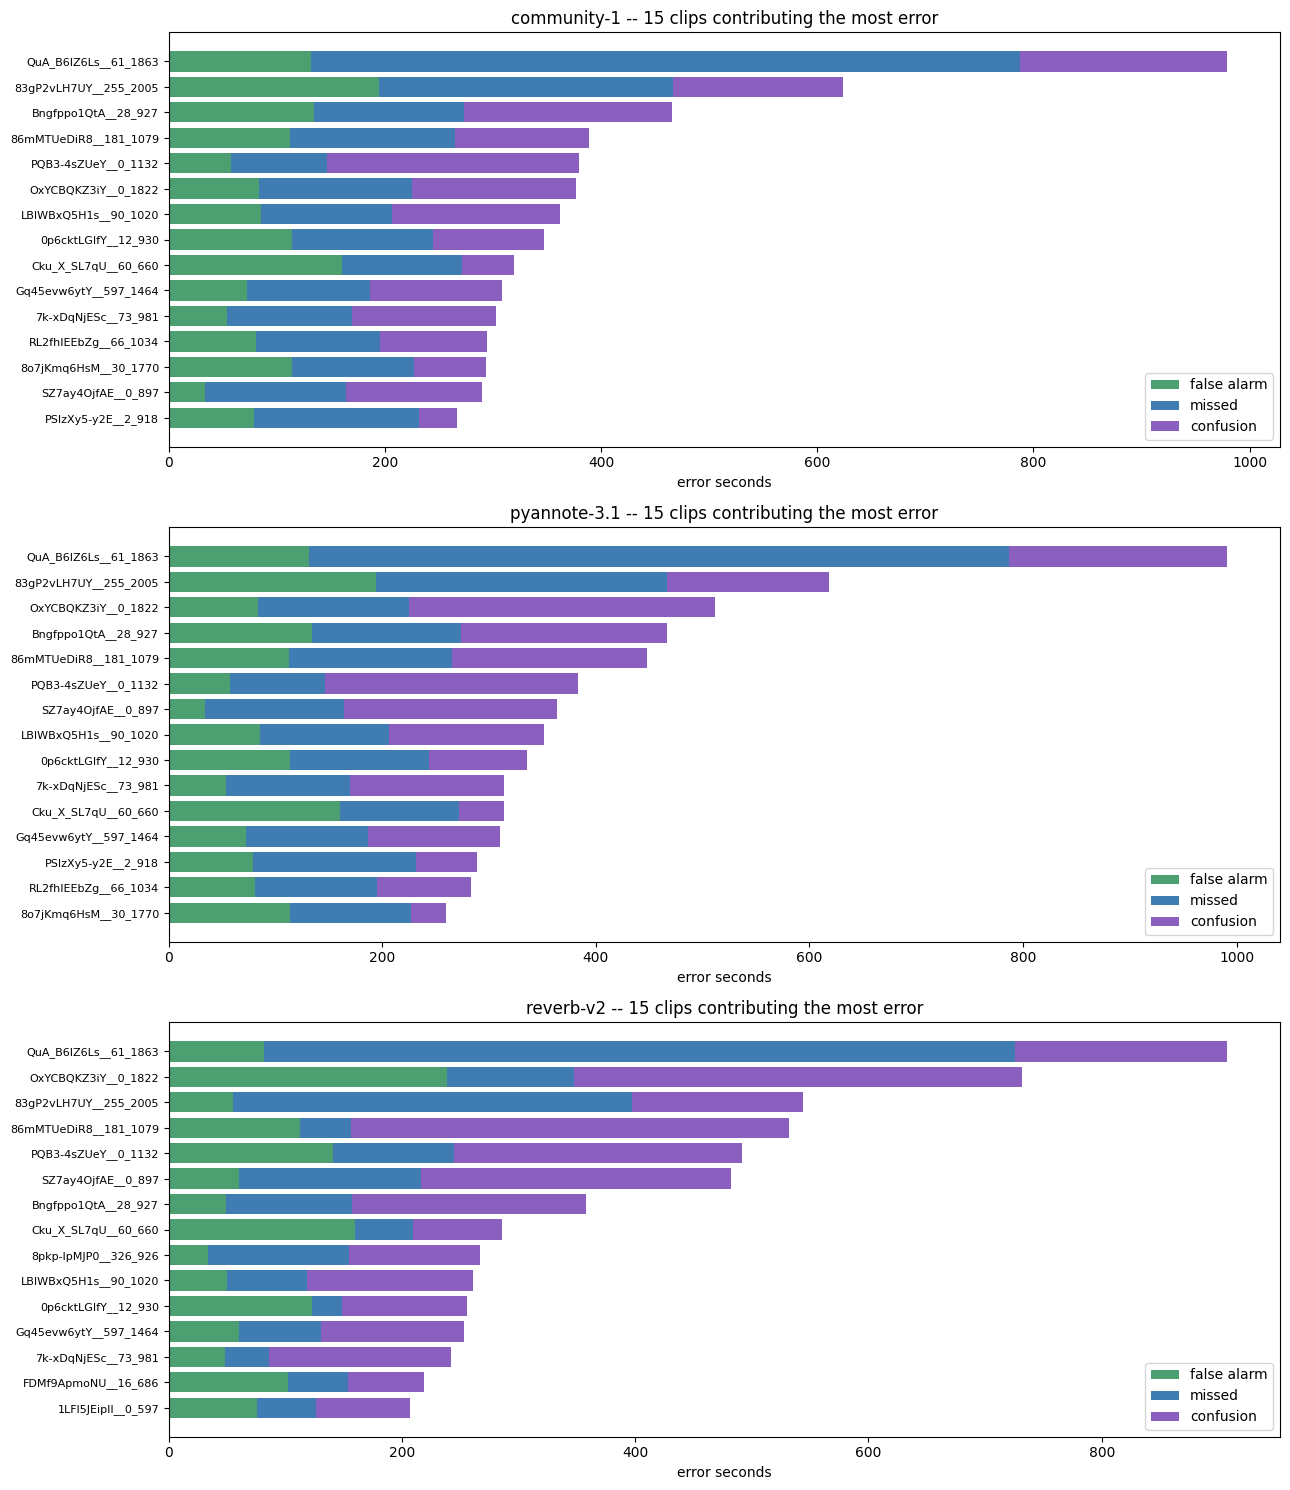

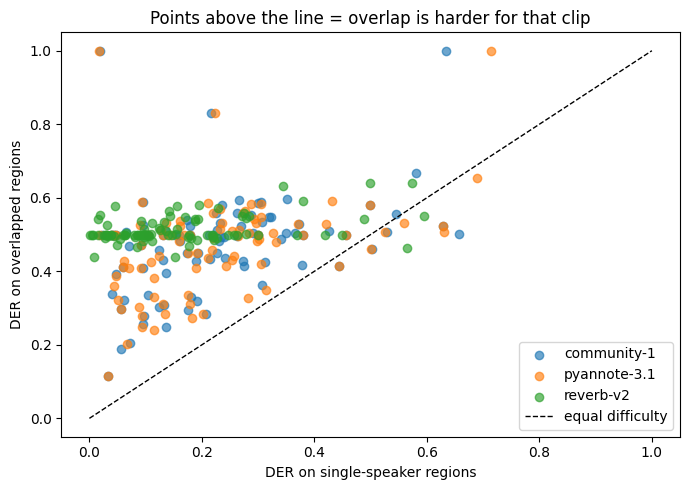

In [25]:
if len(metrics):
    import matplotlib.pyplot as plt

    top = (enriched.sort_values("error_sec", ascending=False)
           .groupby("model").head(15))
    models = sorted(top.model.unique())
    fig, axes = plt.subplots(len(models), 1, figsize=(13, 5 * len(models)), squeeze=False)

    for ax, model in zip(axes[:, 0], models):
        sub = top[top.model == model].sort_values("error_sec")
        ax.barh(sub.clip_id, sub.der_fa_sec, label="false alarm", color="#4C9F70")
        ax.barh(sub.clip_id, sub.der_miss_sec, left=sub.der_fa_sec,
                label="missed", color="#3E7CB1")
        ax.barh(sub.clip_id, sub.der_confusion_sec,
                left=sub.der_fa_sec + sub.der_miss_sec, label="confusion", color="#8B5FBF")
        ax.set_title(f"{model} -- 15 clips contributing the most error")
        ax.set_xlabel("error seconds")
        ax.tick_params(axis="y", labelsize=8)
        ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    # overlap vs single-speaker: the condition that actually separates models
    fig, ax = plt.subplots(figsize=(7, 5))
    for model in models:
        sub = enriched[(enriched.model == model) & enriched.overlap_der.notna()]
        ax.scatter(sub.single_speaker_der, sub.overlap_der, alpha=0.65, label=model)
    lim = [0, max(1.0, enriched.overlap_der.max(skipna=True) or 1.0)]
    ax.plot(lim, lim, "k--", lw=1, label="equal difficulty")
    ax.set_xlabel("DER on single-speaker regions")
    ax.set_ylabel("DER on overlapped regions")
    ax.set_title("Points above the line = overlap is harder for that clip")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2.7 — Export the standalone error explorer

Writes a self-contained `error_explorer/` you download once and open locally.
No hosted runtime, no backend, no build step, no internet.

Everything it shows was computed here and serialised — the browser does no metric
arithmetic. That is deliberate: a second implementation in JavaScript would be
free to drift from the one that produced the benchmark. The exported MISS / FA /
CONFUSION regions are **verified at export time** to reproduce pyannote's own DER
components to within a microsecond, and the result is recorded in
`data/clips.json` so the UI can warn you if it ever fails.

Audio is not bundled by default — the corpus is 1.3 GB and does not belong in a
git repo. The timeline, error regions and filtering all work without it; copy
individual WAVs into `error_explorer/audio/` for the clips you want to hear, or
pass `copy_audio=True`.

To use it:

```bash
cd error_explorer
python -m http.server 8000
# open http://localhost:8000
```

In [26]:
from sarvam_diar import explorer

if not len(metrics):
    print("nothing to export -- run 2.1/2.2 first")
else:
    out = explorer.export(
        cfg, metrics, references, hypotheses,
        out_dir=cfg.root / "error_explorer",
        copy_audio=False,   # True bundles ~1.3 GB of WAV
        verify=True,        # assert regions reproduce the scored components
    )

    import json
    manifest = json.load(open(out / "data" / "clips.json"))
    bad = manifest["verification"]["mismatches"]
    print(f"\n{manifest['n_clips']} clips, models={manifest['models']}")
    print(f"verification mismatches: {len(bad)}"
          + ("  <-- regions would NOT match the metric, do not trust the view" if bad else "  (regions match the metric)"))

    size = sum(f.stat().st_size for f in out.rglob("*") if f.is_file())
    print(f"export size: {size/1e6:.1f} MB at {out}")
    print("\nDownload the folder, then:")
    print("    cd error_explorer && python -m http.server 8000")
    print("    open http://localhost:8000")

    # Optional: zip it so it downloads as one file from the Output tab.
    import shutil
    zip_path = shutil.make_archive(str(cfg.root / "error_explorer"), "zip", root_dir=out)
    print(f"\nzipped -> {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)")
    if IN_KAGGLE:
        print("\nThe zip is under /kaggle/working -- download it from the Output"
              "\ntab on the right after the notebook finishes, or 'Save Version'"
              "\nto persist it.")

08:48:06 | INFO    | sarvam_diar | error explorer -> /kaggle/working/sarvam_diarization/error_explorer (99 clips, models=['community-1', 'pyannote-3.1', 'reverb-v2'], audio_bundled=False)

99 clips, models=['community-1', 'pyannote-3.1', 'reverb-v2']
verification mismatches: 0  (regions match the metric)
export size: 35.8 MB at /kaggle/working/sarvam_diarization/error_explorer

Download the folder, then:
    cd error_explorer && python -m http.server 8000
    open http://localhost:8000

zipped -> /kaggle/working/sarvam_diarization/error_explorer.zip (2.1 MB)

The zip is under /kaggle/working -- download it from the Output
tab on the right after the notebook finishes, or 'Save Version'
to persist it.


---

# Step 3 — ASR on diarized segments

Speaker-attributed transcripts from more than one STT system, scored with
**cpWER** and **WDER**, plus plain **WER** and **DI-cpWER** as diagnostics.

**Two strategies, and the difference between them is a result.**

* *Per-segment* — cut the audio at the diarized turn boundaries and transcribe
  each turn. Attribution is exact by construction. This is the literal reading
  of the brief, and for Sarvam it is the **only** option: Saaras returns exactly
  one timestamp span per request (measured, across v3/v4, 5 s/20 s, every mode),
  so there are no word times to attribute with.
* *Long-form* — transcribe the clip once with word timestamps and assign each
  word to the turn covering it. Only Whisper can do this, so running it on
  Whisper isolates the **strategy** effect rather than confounding it with the
  system.

Both systems therefore run per-segment for the like-for-like comparison, and
Whisper additionally runs long-form.

**Turns come from `reverb-v2`** — 2,650 merged segments at a median 7.66 s,
against community-1's 10,279 at 1.13 s. Fewer, longer segments give the
recogniser context instead of fragments. Adjacent same-speaker turns are merged
first; that is an ASR segmentation choice and the scored diarization is
untouched.

**No language is ever hinted.** Sarvam is called with `language_code="unknown"`
and Whisper with `language=None`. `ref_lang_script` is derived from the
ground-truth transcript, so passing it would be exactly the leak the brief
forbids. What each system detects is recorded and can be scored separately.


## 3.1 — Systems and inputs

In [27]:
# faster-whisper, not whisperx: whisperx pins an older pyannote and would fight
# the Step 2 environment, while the only part of it we want -- assigning words
# to speakers -- is asr.assign_words(). faster-whisper is CTranslate2 underneath
# and pulls no pyannote at all, so it coexists with what is already installed.
%pip install -q faster-whisper rapidfuzz

from sarvam_diar import asr, text_metrics as tm

# This kernel keeps whatever it imported first, so a pulled fix does not reach
# a re-run cell until the modules are purged. Name the symbols this section
# needs and fail here rather than deep inside a library.
utils.assert_fresh("SARVAM_MAX_SEC", "merge_same_speaker", "run_segmented",
                   "oracle_ceiling", module=asr)
utils.assert_fresh("di_cpwer", "verify_assignment_exact", module=tm)

# SARVAM_API_KEY: .env at the working root, or Kaggle Secrets / Colab Secrets.
# Leave SARVAM off if you have no key -- Whisper alone still satisfies nothing,
# the brief wants more than one system, but the cells below will run.
try:
    _k = asr.resolve_sarvam_key(cfg)
    print(f"Sarvam key: {_k[:6]}...{_k[-4:]}")
    SARVAM_SYSTEMS = ["sarvam-saaras-v3", "sarvam-saaras-v4"]
except Exception as exc:
    print(f"no Sarvam key ({exc}); running Whisper only")
    SARVAM_SYSTEMS = []

import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

# large-v3 was measured at RTF ~0.5 on a T4 -- roughly 6.6 h for this corpus,
# which does not fit a session. large-v3-turbo has 4 decoder layers instead of
# 32 and decoding is where long-form time goes. It stays MULTILINGUAL, which the
# distil-* models are not -- they are English-only and so unusable across nine
# Indic scripts. Switch back to "whisper-large-v3" if there is time to spend.
WHISPER = "whisper-large-v3-turbo"

DIAR = "reverb-v2"          # which diarization the ASR is attributed against
import dataclasses
ready = [dataclasses.replace(ci, wav_path=str(cfg.wav_path(cid)))
         for cid, ci in inputs.items() if cfg.wav_path(cid).exists()]
have = sum(1 for c in ready if diarization.is_done(cfg, DIAR, c.clip_id))
print(f"{len(ready)} clips with audio; {have} have {DIAR} turns")
assert have, f"no {DIAR} hypotheses -- run Step 2 first"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 12.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 64.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 54.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.5/39.5 MB 49.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 74.8 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.
08:48:18 | INFO    | sarvam_diar | loaded 2 key(s) from /kaggle/working/sarvam_diarization/.env
Sarvam key: sk_474...elIK
GPU: Tesla T4
99 clips with audio; 99 have reverb-v2 turns


## 3.2 — Smoke gate

In [28]:
# --- SMOKE GATE ------------------------------------------------------------
# Whisper pads every input to a fixed 30 s window, so a 1 s segment costs the
# same encoder pass as a 30 s one: per-segment cost tracks the NUMBER of calls,
# not the audio length. Measure both paths on two clips before committing.
#
# Batched long-form is timed too, but it is NOT the default: batching requires
# Whisper's own Silero VAD, which is a second speech/non-speech decision on top
# of the diarizer's, and whatever it drops becomes an unrecoverable miss. Use it
# only if the unbatched projection does not fit the session, and say so in the
# writeup if you do.
import time

probe = sorted(ready, key=lambda c: c.duration)
probe = [probe[0], probe[len(probe) // 2]]      # not the longest: slowest, and
                                                # tells us the least
total_audio = sum(c.duration for c in ready)

for label, kwargs in (("long-form (greedy, no extra VAD)", dict(beam_size=1)),
                      ("long-form (batched, Whisper VAD)", dict(beam_size=1, batch_size=8))):
    print(label)
    rtfs = []
    for c in probe:
        t = time.time()
        words, meta = asr.transcribe_whisper(cfg, Path(c.wav_path),
                                             word_timestamps=True, **kwargs)
        el = time.time() - t
        rtfs.append(el / c.duration)
        print(f"  {c.clip_id:<26}{c.duration:7.0f}s  {el:7.1f}s  rtf {el/c.duration:.3f}"
              f"  {len(words):>5} words  {meta.get('detected_language')}")
    mean = sum(rtfs) / len(rtfs)
    print(f"  mean RTF {mean:.3f}  ->  {mean*total_audio/3600:.1f} h for all "
          f"{len(ready)} clips\n")

print("per-segment -- one call per turn, for the like-for-like comparison")
for system in ([WHISPER] + SARVAM_SYSTEMS[:1]):
    c = probe[0]
    turns = asr.merge_same_speaker(diarization.load_hypothesis(cfg, DIAR, c.clip_id), 1.0)
    t = time.time()
    segs, meta = asr.transcribe_segments(cfg, system, Path(c.wav_path), turns, workers=4)
    el = time.time() - t
    per = el / max(len(segs), 1)
    print(f"  {system:<24}{len(segs):>4} segs  {el:6.1f}s  ({per:.2f}s/seg)"
          f"  -> {per*2650/60:.0f} min for all 2,650 segments")


long-form (greedy, no extra VAD)
08:48:19 | INFO    | sarvam_diar | loading faster-whisper large-v3 on cuda (float16) -- the first call also downloads ~3 GB
08:48:32 | INFO    | sarvam_diar | model ready in 13s
  T3I2T-cfhG4__160_210           50s     56.5s  rtf 1.129    112 words  mr
  Pjre5dpnKGA__0_330            330s    252.5s  rtf 0.765    193 words  kn
  mean RTF 0.947  ->  11.6 h for all 99 clips

long-form (batched, Whisper VAD)
  T3I2T-cfhG4__160_210           50s      5.1s  rtf 0.102     92 words  mr
  Pjre5dpnKGA__0_330            330s     17.8s  rtf 0.054    229 words  kn
  mean RTF 0.078  ->  1.0 h for all 99 clips

per-segment -- one call per turn, for the like-for-like comparison
08:53:50 | INFO    | sarvam_diar | loading faster-whisper large-v3-turbo on cuda (float16) -- the first call also downloads ~3 GB
08:54:00 | INFO    | sarvam_diar | model ready in 9s
  whisper-large-v3-turbo     2 segs    14.0s  (6.98s/seg)  -> 308 min for all 2,650 segments
08:54:04 | INFO    |

## 3.3 — Per-segment sweep

In [ ]:
# --- sweeps ----------------------------------------------------------------
# Whisper LONG-FORM over everything: 99 model calls rather than ~2,650, and it
# is the strategy Step 4 needs anyway, since reasoning about a transcript
# requires word times.
# Whisper PER-SEGMENT over a subset only: enough to measure the strategy gap
# without paying for it 99 times.
# Sarvam per-segment over everything, because Saaras returns no word timings and
# has no other option.
RUN_ASR = True
SEGMENT_SUBSET = 15        # clips for the Whisper per-segment comparison

if RUN_ASR:
    lf = asr.run(cfg, ready, flags=flags, systems=[WHISPER])
    if len(lf):
        display(lf[["clip_id", "n_words", "elapsed_sec", "rtf", "detected_language"]].head(8))

    if SARVAM_SYSTEMS:
        asr.run_segmented(cfg, ready, diar_model=DIAR, systems=SARVAM_SYSTEMS,
                          flags=flags, merge_gap=1.0, workers=4)

    subset = sorted(ready, key=lambda c: c.duration)[:SEGMENT_SUBSET]
    print(f"\nWhisper per-segment on {len(subset)} clips "
          f"({sum(c.duration for c in subset)/60:.0f} min of audio) for the "
          f"strategy comparison")
    asr.run_segmented(cfg, subset, diar_model=DIAR, systems=[WHISPER],
                      flags=flags, merge_gap=1.0)
else:
    print("RUN_ASR is False -- scoring whatever is already checkpointed")


08:55:18 | INFO    | sarvam_diar | [whisper-large-v3-turbo 1/99] 0AEEA8NyVwY__11_609  896 words  64.5s  rtf 0.108  lang=hi
08:55:26 | INFO    | sarvam_diar | [whisper-large-v3-turbo 2/99] 0SoItGfM_sY__7_88  220 words  8.8s  rtf 0.108  lang=en
08:55:43 | INFO    | sarvam_diar | [whisper-large-v3-turbo 3/99] 0VEwL9XZ0LY__261_557  701 words  16.2s  rtf 0.055  lang=en
08:57:33 | INFO    | sarvam_diar | [whisper-large-v3-turbo 4/99] 0esIFSOAcFs__0_913  1577 words  110.2s  rtf 0.121  lang=hi
08:58:49 | INFO    | sarvam_diar | [whisper-large-v3-turbo 5/99] 0p6cktLGIfY__12_930  2496 words  76.6s  rtf 0.083  lang=en
09:01:56 | INFO    | sarvam_diar | [whisper-large-v3-turbo 6/99] 13VBh0Z6QmE__0_904  963 words  186.4s  rtf 0.206  lang=ta
09:02:58 | INFO    | sarvam_diar | [whisper-large-v3-turbo 7/99] 1LFl5JEipII__0_597  1394 words  61.9s  rtf 0.104  lang=en
09:03:06 | INFO    | sarvam_diar | [whisper-large-v3-turbo 8/99] 2HGP34TNvjg__84_194  189 words  8.0s  rtf 0.073  lang=en
09:03:32 | INFO  

## 3.4 — Long-form Whisper

In [ ]:
# Long-form already ran above, over every clip. Kept as its own step only to
# make the resume path obvious: re-running this is a no-op once checkpointed.
lf = asr.run(cfg, ready, flags=flags, systems=[WHISPER])
print(f"{len(lf)} long-form transcripts on disk")


## 3.5 — Score

In [ ]:
# --- score: WER, cpWER, DI-cpWER, WDER -------------------------------------
from sarvam_diar import reference as refmod

# Hungarian is EXACT for cpWER, not an approximation of a permutation search: a
# speaker-pair's error count does not depend on the other pairs, so the total is
# a sum of independent cells. Checked here rather than asserted.
_probe = [cid for cid in references][:12]
_checks = []
for cid in _probe:
    ref = references[cid]
    rt = {k: v.split() for k, v in refmod.speaker_texts(ref).items()}
    if not rt:
        continue
    keys = list(rt)
    hyp = {f"S{i}": rt[k] for i, k in enumerate(keys[1:] + keys[:1])}   # permuted
    _checks.append(tm.verify_assignment_exact(rt, hyp))
_ok = [c for c in _checks if c.get("checked")]
print(f"Hungarian vs brute force: {sum(c['agree'] for c in _ok)}/{len(_ok)} agree "
      f"(up to {max((c['n_permutations'] for c in _ok), default=0)} permutations)")
assert all(c["agree"] for c in _ok), "Hungarian disagrees with brute force"

rows = []
# Whisper per-segment covers only SEGMENT_SUBSET clips, so its rows are a
# subset by design; is_done() below simply skips the clips it never ran.
for system in [WHISPER] + SARVAM_SYSTEMS:
    tag = f"{system}@{DIAR}"
    for cid, ref in references.items():
        if not asr.is_done(cfg, tag, cid):
            continue
        pairs = asr.load_pairs(cfg, tag, cid)
        row = tm.score_transcript(
            {k: v.split() for k, v in refmod.speaker_texts(ref).items()},
            asr.speaker_texts_from_words(pairs),
            refmod.word_stream(ref), pairs)
        row.update(clip_id=cid, asr_system=system, diar_model=DIAR,
                   strategy="segment", script=ref.stats.get("lang_script"))
        rows.append(row)

# long-form Whisper, attributed by time overlap against the same turns
for cid, ref in references.items():
    if not asr.is_done(cfg, WHISPER, cid):
        continue
    if not diarization.is_done(cfg, DIAR, cid):
        continue
    words = asr.load_words(cfg, WHISPER, cid)
    turns = diarization.load_hypothesis(cfg, DIAR, cid)
    pairs = [(tok, spk)
             for w, spk in asr.assign_words(words, turns)
             for tok in refmod.normalize_text(w, strip_gloss=False).split()]
    row = tm.score_transcript(
        {k: v.split() for k, v in refmod.speaker_texts(ref).items()},
        asr.speaker_texts_from_words(pairs),
        refmod.word_stream(ref), pairs)
    row.update(clip_id=cid, asr_system=WHISPER, diar_model=DIAR,
               strategy="longform", script=ref.stats.get("lang_script"))
    rows.append(row)

asr_scores = pd.DataFrame(rows)
if len(asr_scores):
    asr_scores.to_csv(cfg.step3_metrics_csv, index=False)
    print(f"\nscored {len(asr_scores)} (system, strategy, clip) rows")
else:
    print("nothing scored yet -- run the sweep cells above")


## 3.6 — Results

In [ ]:
if not len(asr_scores):
    print("nothing to report yet")
else:
    print("=== CORPUS (pooled: sum errors / sum reference words) ===")
    out = []
    for (system, strategy), g in asr_scores.groupby(["asr_system", "strategy"]):
        out.append({"asr_system": system, "strategy": strategy,
                    **tm.summarise(g.to_dict("records"))})
    corpus = pd.DataFrame(out).sort_values("cpwer").reset_index(drop=True)
    display(corpus[["asr_system", "strategy", "n_clips", "wer", "cpwer",
                    "di_cpwer", "cp_minus_di_cp", "wder", "n_ref_words"]].round(4))

    # The floor. A cpWER has to be read against this, not against zero: with a
    # perfect ASR and a perfect diarization, overlapped speech still costs this
    # much, because one transcript cannot carry two simultaneous speakers.
    ceil = asr.oracle_ceiling(cfg, references)
    print(f"\nOVERLAP CEILING (oracle ASR + oracle diarization): "
          f"cpWER {ceil['cpwer']:.4f}  WDER {ceil['wder']:.4f}  "
          f"(exactly 0 on the {ceil['n_clips_no_overlap']} clips with no overlap)")
    best = corpus.iloc[0]
    print(f"best system is {best['cpwer']:.4f}, i.e. "
          f"{best['cpwer']-ceil['cpwer']:.4f} above the achievable floor")

    print("\n=== by script (pooled) ===")
    per = []
    for (system, strategy, script), g in asr_scores.groupby(
            ["asr_system", "strategy", "script"]):
        per.append({"asr_system": system, "strategy": strategy, "script": script,
                    **tm.summarise(g.to_dict("records"))})
    display(pd.DataFrame(per).pivot_table(
        index="script", columns=["asr_system", "strategy"], values="cpwer").round(3))


## 2.8 — Keep your results

`/kaggle/working` is wiped when the session ends, so a finished sweep is lost
unless you do one of these:

* **Save Version** (top right) — commits the notebook and everything under
  `/kaggle/working` as its Output. This is the one that lets you *resume*: next
  session, attach that output via **Input → Add Input → Your Work** and set
  `PREV_RESULTS` in cell 1.1.
* **Download the zip** the cell below writes — enough to analyse offline or to
  open the error explorer, but you cannot resume a sweep from it without
  re-uploading.

The bundle is small (~1–2 MB of RTTM plus sidecars); the 1.3 GB of audio is not
included, since it already lives in your input dataset.

In [ ]:
import shutil, os
from pathlib import Path

# Everything worth keeping, excluding the audio (which is in the input dataset)
# and the scratch dir.
BUNDLE = Path("/kaggle/working/step2_results" if IN_KAGGLE else "./step2_results")
shutil.rmtree(BUNDLE, ignore_errors=True)
BUNDLE.mkdir(parents=True, exist_ok=True)

carried = []
for sub in ("hypotheses", "hypotheses_oracle", "results", "reference", "error_explorer", "logs"):
    src = cfg.root / sub
    if src.exists() and any(src.rglob("*")):
        shutil.copytree(src, BUNDLE / sub, dirs_exist_ok=True)
        carried.append(f"{sub} ({sum(1 for f in src.rglob('*') if f.is_file())} files)")

if carried:
    zip_path = shutil.make_archive(str(BUNDLE), "zip", root_dir=BUNDLE)
    print("bundled:", ", ".join(carried))
    print(f"\n{zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)")
    print("\nDownload it from the Output tab on the right.")
    print("To RESUME a sweep next session, use Save Version instead and attach")
    print("that output as an Input (see cell 1.1 PREV_RESULTS).")
else:
    print("nothing to bundle yet -- run Step 2 first")

bundled: hypotheses (594 files), results (7 files), reference (200 files), error_explorer (104 files)

/kaggle/working/step2_results.zip  (3.5 MB)

Download it from the Output tab on the right.
To RESUME a sweep next session, use Save Version instead and attach
that output as an Input (see cell 1.1 PREV_RESULTS).
